Developing L-curves

In [20]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [21]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/IO/calslope/"
else:
    cache = "/Volumes/morgana2/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/IO/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/IO/")

state = np.load(
    os.path.join(model_cache, "ode/test_state.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [22]:
# Build the ramp model
n_latent = 6
keys = jr.split(jr.PRNGKey(0), 3)
encoder = amigo.latent_ode_models.LatentEncoder(
    n_latent=n_latent, width=6, depth=2, key=keys[0], pools=[0, 1]
)
latent_ode = amigo.latent_ode_models.LatentODE(
    n_latent=n_latent, width=3, depth=2, key=keys[1]
)
decoder = amigo.latent_ode_models.LatentDecoder(
    n_latent=n_latent, depth=3, key=keys[2], up_samples=[1, 2], out_channels=2
)

# ramp = LatentODERamp(encoder=encoder, latent_ode=latent_ode, decoder=decoder)
ode_ramp = amigo.latent_ode_models.GainDiffusionRamp(
    encoder=encoder, latent_ode=latent_ode, decoder=decoder
)

# Loading in data

In [23]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 18)

In [24]:
source_size = 120
shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = dorito.build_model.wavelet_prior(source_size)

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    [],
    # cal_files[0:3],
    sci_files[0:1],
    # cal_files,
    # sci_files,
    # [],
    state=state,
    # width=width,
    # depth=depth,
    ramp_model=ode_ramp,
    extra_priors={
        # "wavelets": shearlets,
        # "wavelets": wavelets,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    # shearletSystem=shearletSystem,
    sci_fit=dorito.model_fits.ResolvedFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init state
init_state = np.load(init_state_cache + "F430M.npy", allow_pickle=True)[()]
for p in [
    "positions",
    "fluxes",
    "aberrations",
    "log_distribution",
]:
    params[p] = init_state[p]
model = model.set("params", params)

model = model.set("FF", np.ones_like(model.FF))

No Teff found for IO, defaulting to 4500K


In [25]:
model = model.set("ramp.values", np.zeros_like(model.ramp.values))

In [26]:
fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

fishers = amigo.fisher.calc_fishers(
    model.set("ramp", None),
    fits,
    # sci_exposures,
    fisher_params,
    overwrite=True,
    cache=fisher_cache,
    recalculate=False,
)

  0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
n_epoch = 250

config = {
    # "positions": sgd(2e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),
    # "log_distribution": adam(2e-2, 7),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 5),
    "fluxes": sgd(2e-2, 0),
    "log_distribution": adam(2e-2, 5),  # , (10, 0.25), b1=0.7),
    # "one_on_fs": sgd(1e2, 6),
    # "wavelets": adam(5e-5, 0),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 1.0e-3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e-3,
    # "ME": None,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        "L1": dorito.stats.L1_on_wavelets,
        "QV": dorito.stats.TSV,
        "ME": dorito.stats.ME,
    },
}

In [ ]:
def lcurve_sweep(
    regulariser: str,  # e.g. "L1", "L2", "TV", "QV", "ME", "SF"
    coeffs,
    model,
    exposures: list,
    args: dict,  # must contain reg_dict and reg_func_dict
    optimisers: dict,
    fishers: dict,
    **optimise_kwargs,
):
    """
    Function to find an optimal regularisation hyperparameter using the l-curve method.

    Parameters
    ----------
    regulariser : str
        Name of the regulariser to be optimised.
    coeffs : array_like
        Regularisation hyperparameters to be tested.
    model : amigo.Model
        Model to be optimised.
    exposures : list
        List of exposures to be used in the optimisation.
    args : dict
        Dictionary containing the regularisation dictionary and regularisation function dictionary.
    optimisers : dict
        Dictionary containing the optimisers to be used in the optimisation.
    fishers : dict
        Dictionary containing the fishers to be used in the optimisation.
    optimise_kwargs : dict
        Additional keyword arguments to be passed to the optimisation function.

    Returns
    -------
    tuple
        Tuple containing the balance, regularisation hyperparameters and log distributions.
    """

    @zdx.filter_jit
    def calc_balance(model, exposures, args, coeff):
        return np.array(
            [
                dorito.stats.prior_data_balance(model, exp, args, coeff)
                for exp in exposures
            ]
        ).sum(0)

    balances = []
    log_dists = []

    for coeff in coeffs:

        args["reg_dict"][regulariser] = coeff

        optim_model, _, _, _ = amigo.fitting.optimise(
            model,
            exposures,
            optimisers,
            fishers,
            args=args,
            **optimise_kwargs,
        )

        balance = calc_balance(optim_model, exposures, args, coeff)
        balances.append(balance)
        log_dists.append(optim_model.log_distribution)

    return np.array(balances).T, coeffs, log_dists

In [32]:
# break

sweep, coeffs, log_dists = lcurve_sweep(
    "QV",
    model,
    fits,
    args,
    config,
    fishers,
    # args=args,
    coeffs=np.logspace(3, 10, 101),
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    # loss_fn=zdx.combine,
    # epochs=n_epoch,
    epochs=200,
    print_grads=False,
)

  0%|          | 0/200 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 303.94
Est time per epoch:  0:00:00
Est run time:  0:00:29
Full Time: 0:00:35
Final Loss: 123.97


  0%|          | 0/200 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 303.94
Est time per epoch:  0:00:00
Est run time:  0:00:37
Full Time: 0:00:36
Final Loss: 123.97


  0%|          | 0/200 [00:00<?, ?it/s]

...

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 18,069.93
Est time per epoch:  0:00:00
Est run time:  0:00:38
Full Time: 0:00:37
Final Loss: 2,834.03


  0%|          | 0/200 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 21,229.49
Est time per epoch:  0:00:00
Est run time:  0:00:37
Full Time: 0:00:37
Final Loss: 3,169.97


  0%|          | 0/200 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 24,941.77
Est time per epoch:  0:00:00
Est run time:  0:00:37
Full Time: 0:00:37
Final Loss: 3,548.42


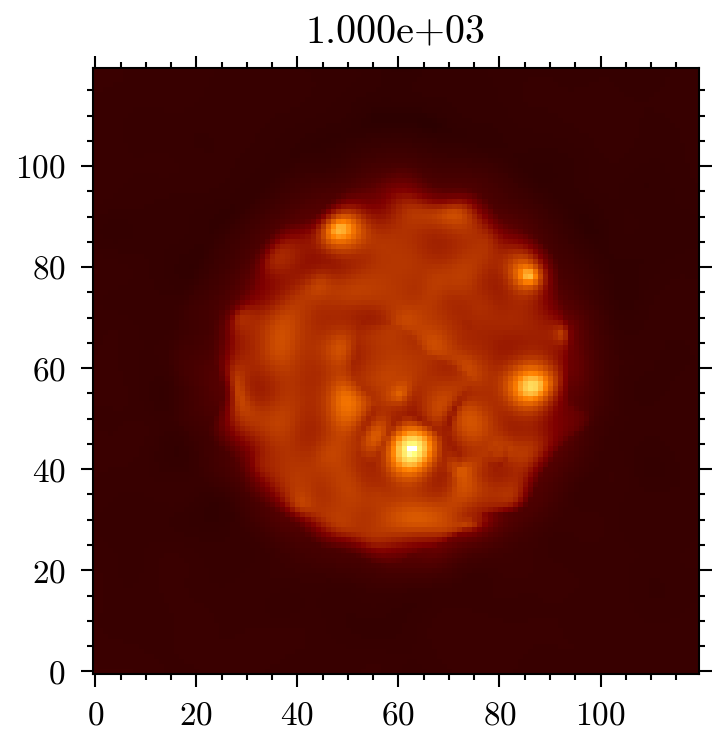

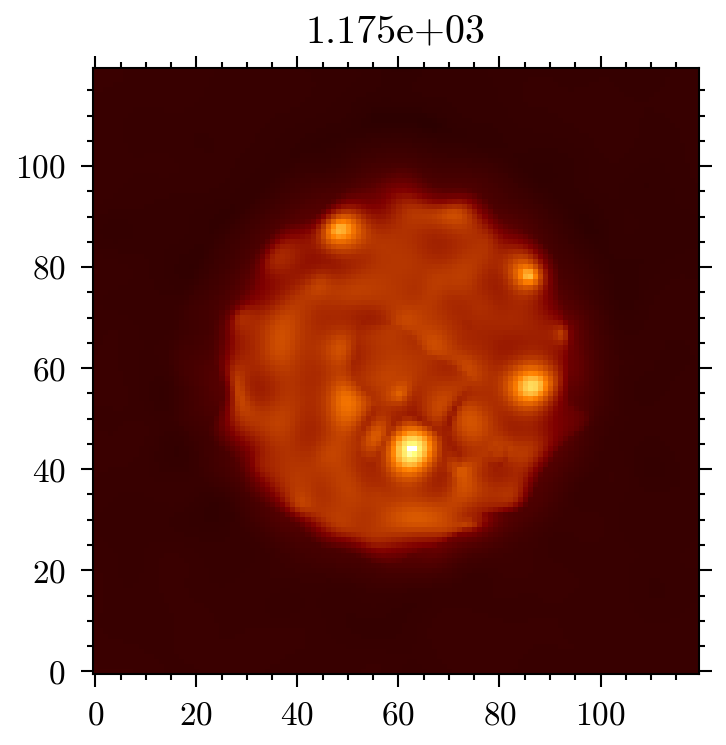

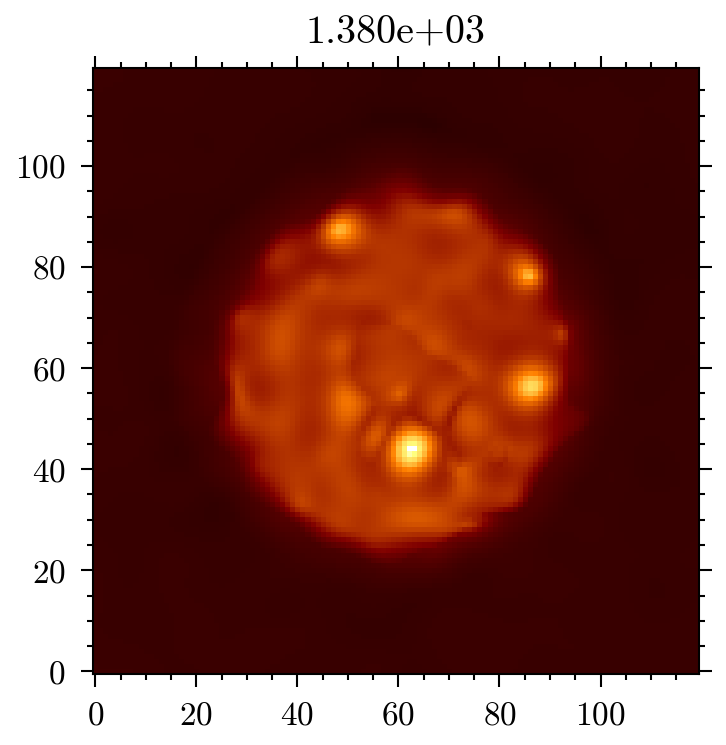

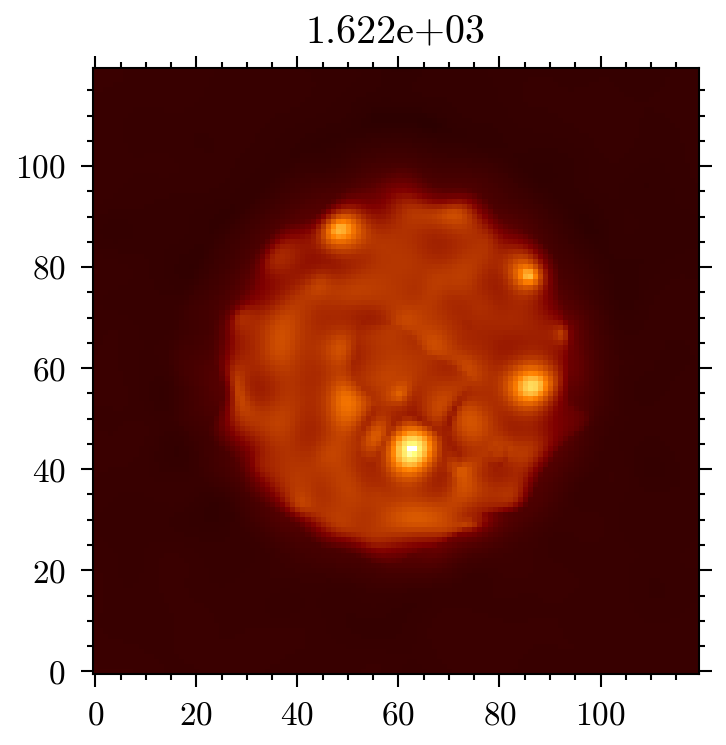

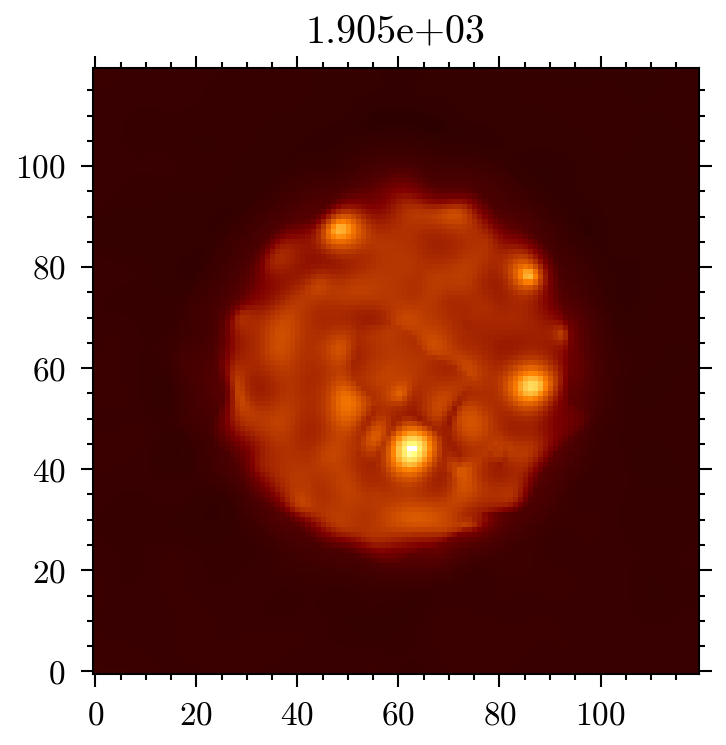

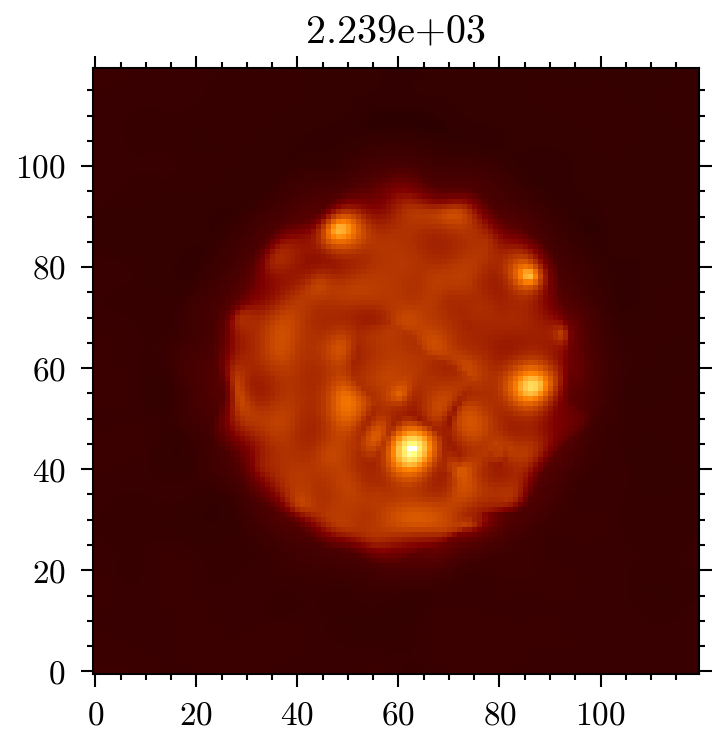

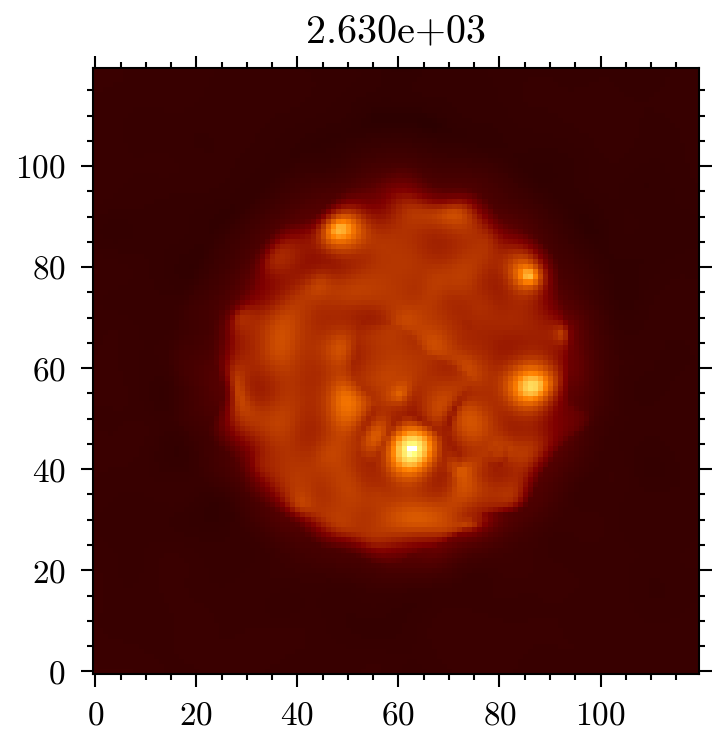

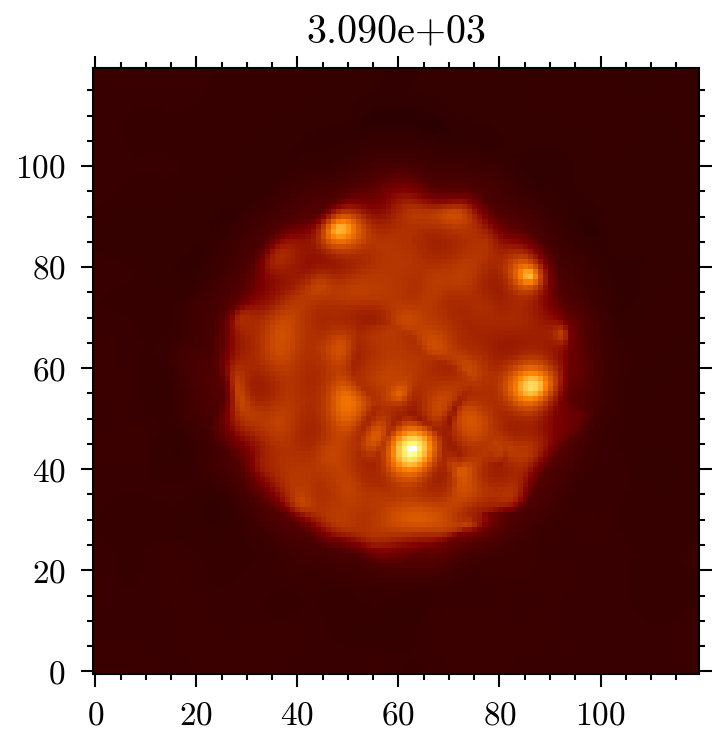

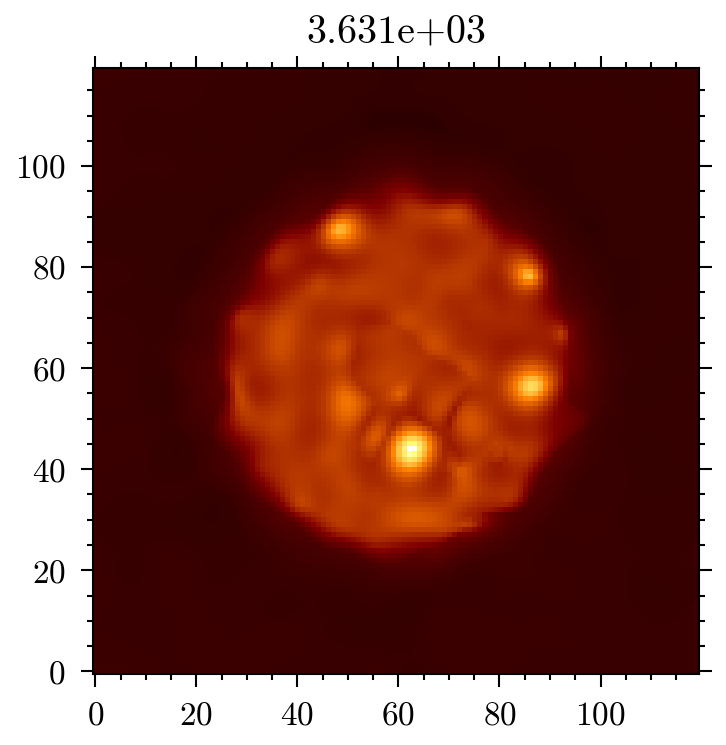

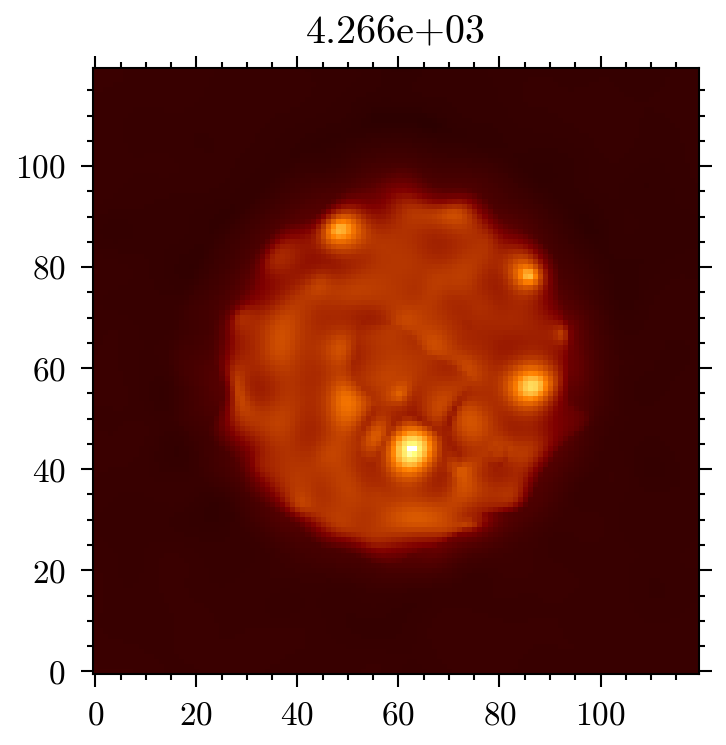

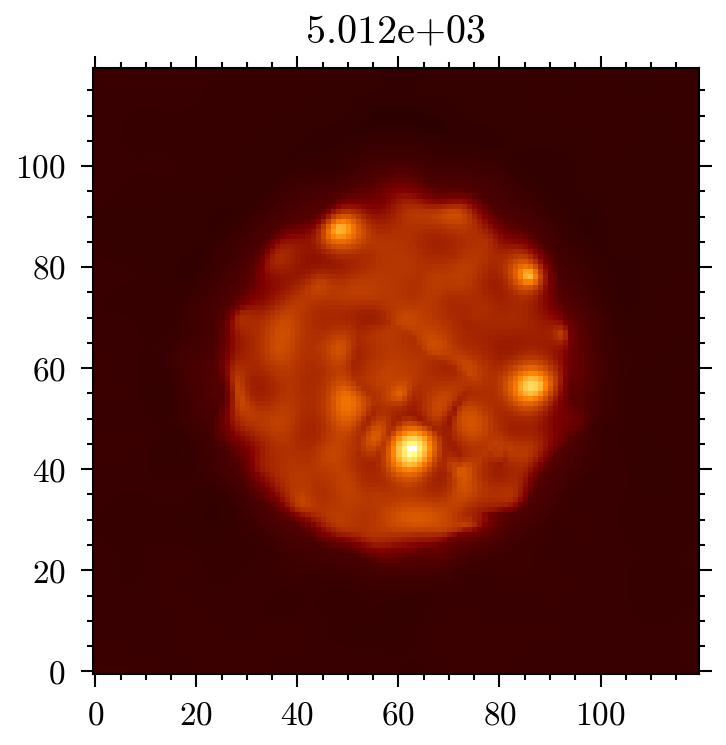

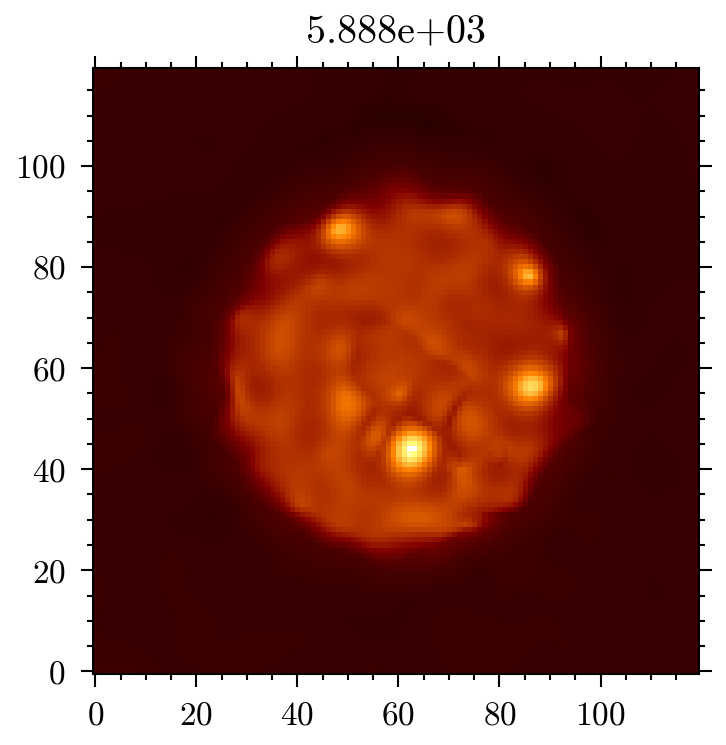

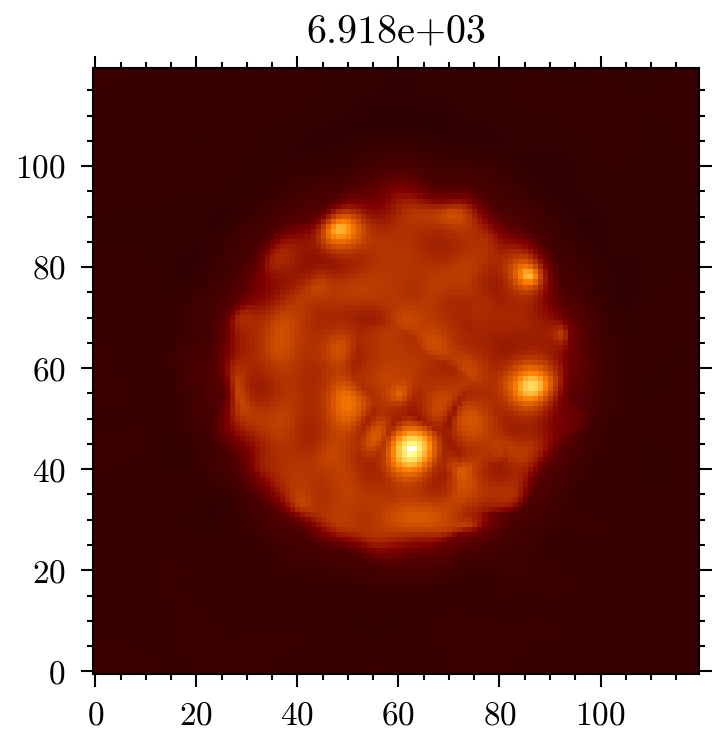

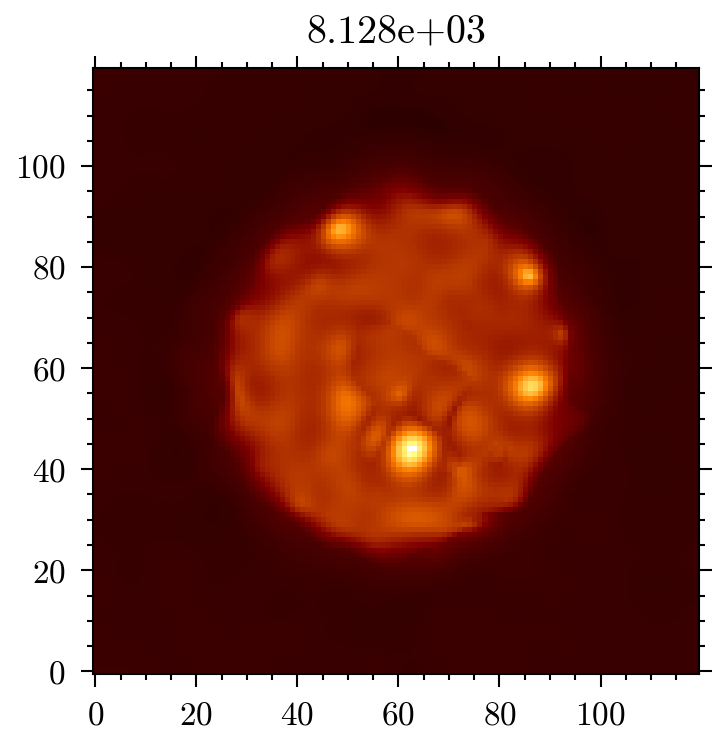

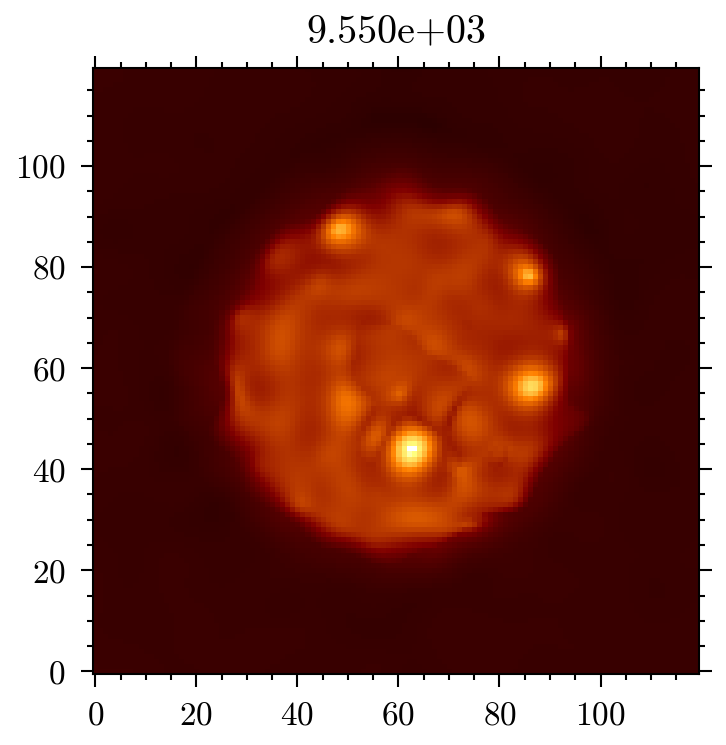

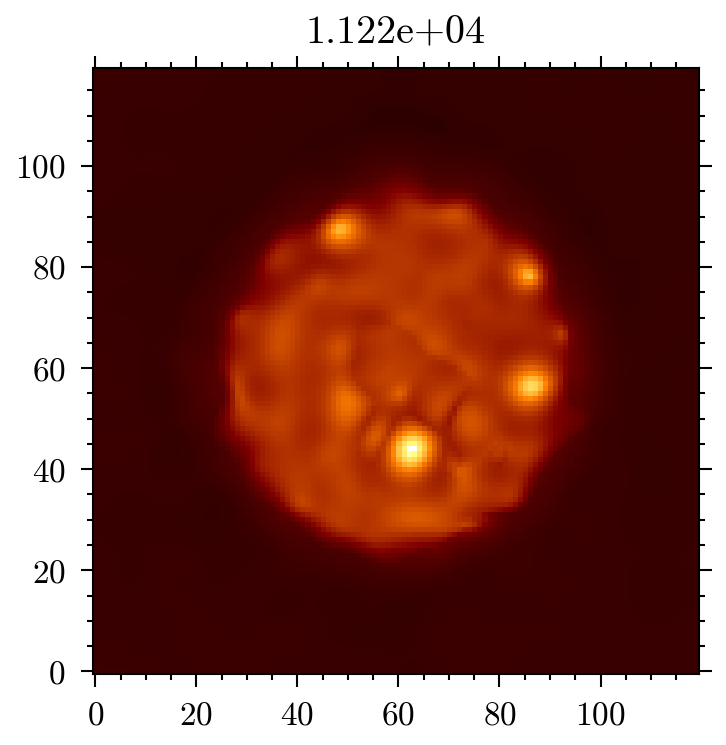

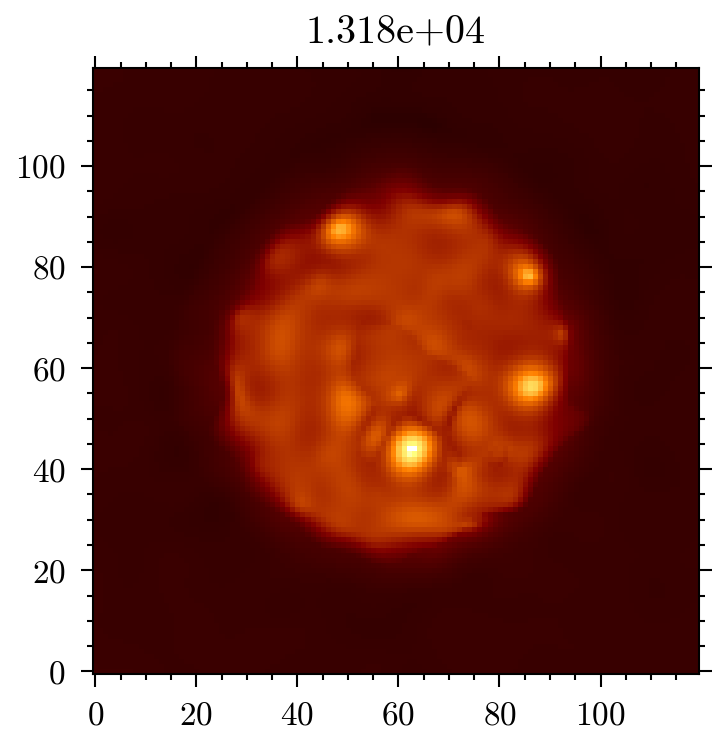

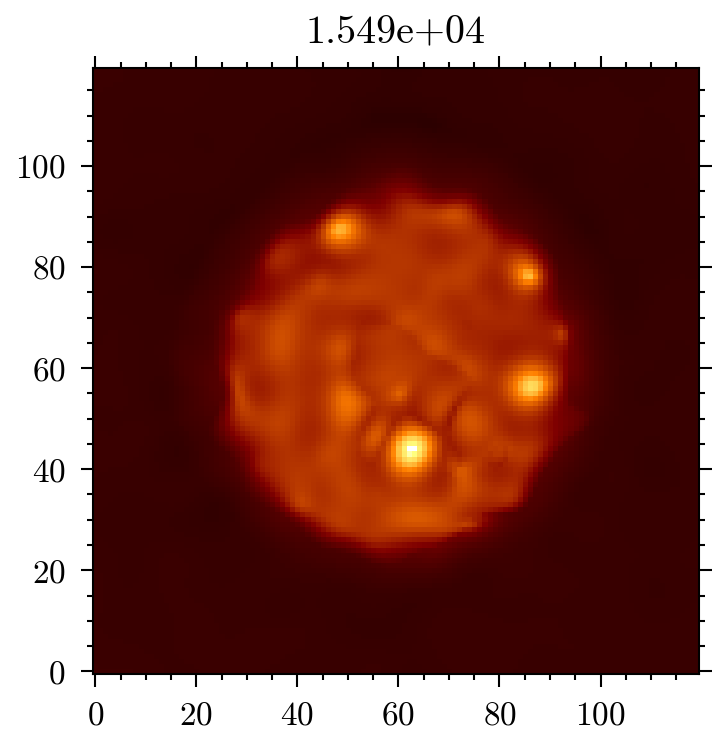

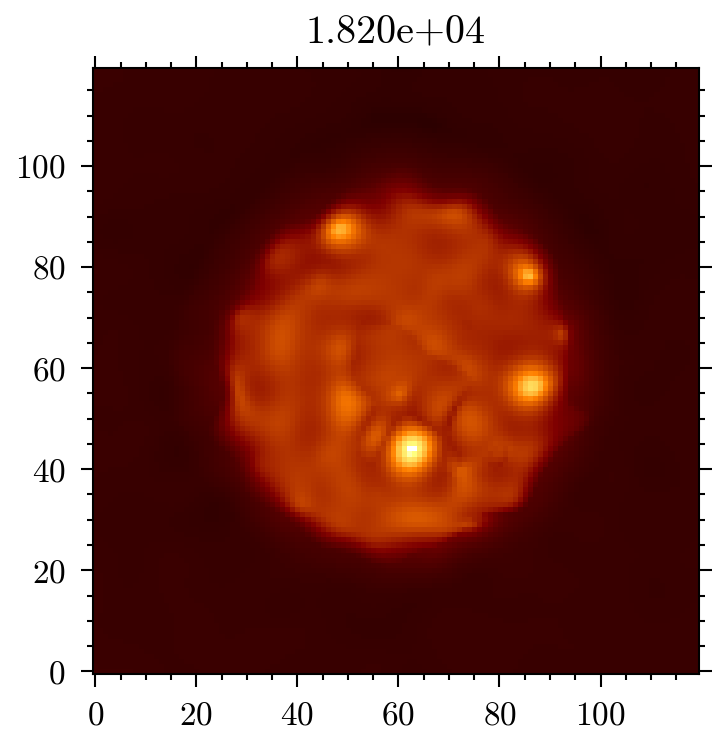

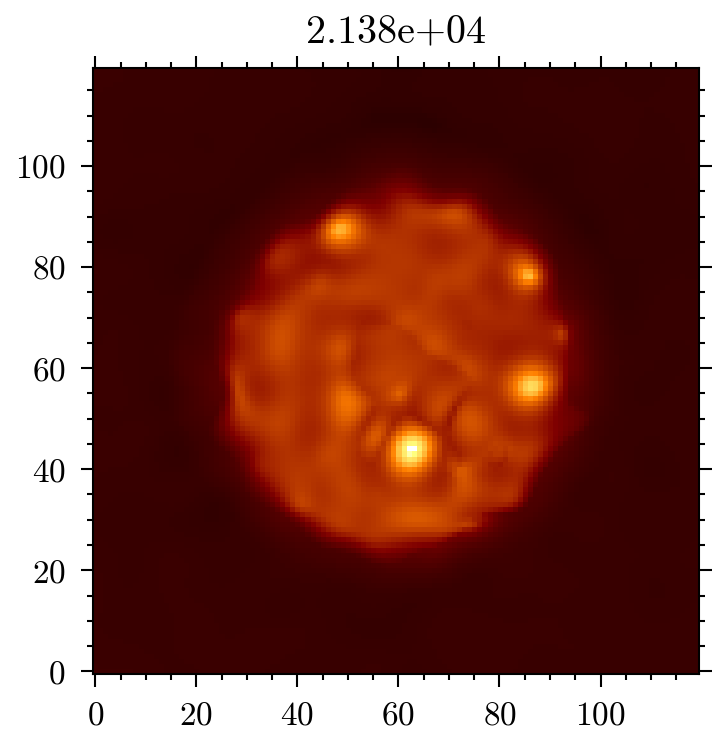

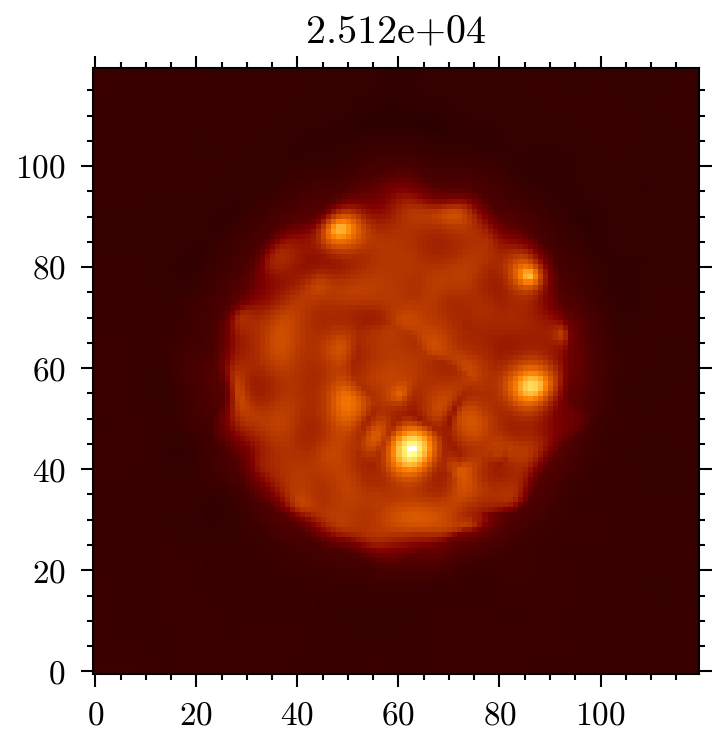

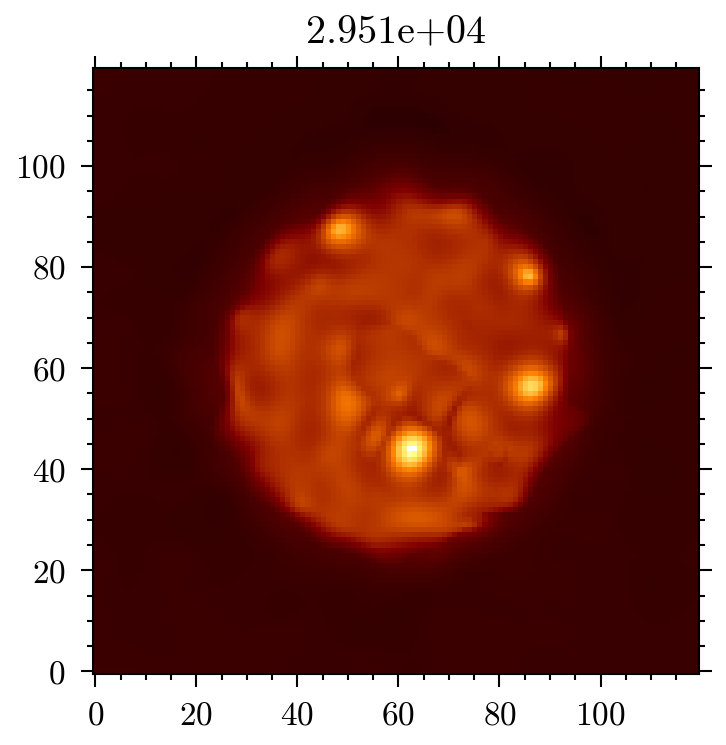

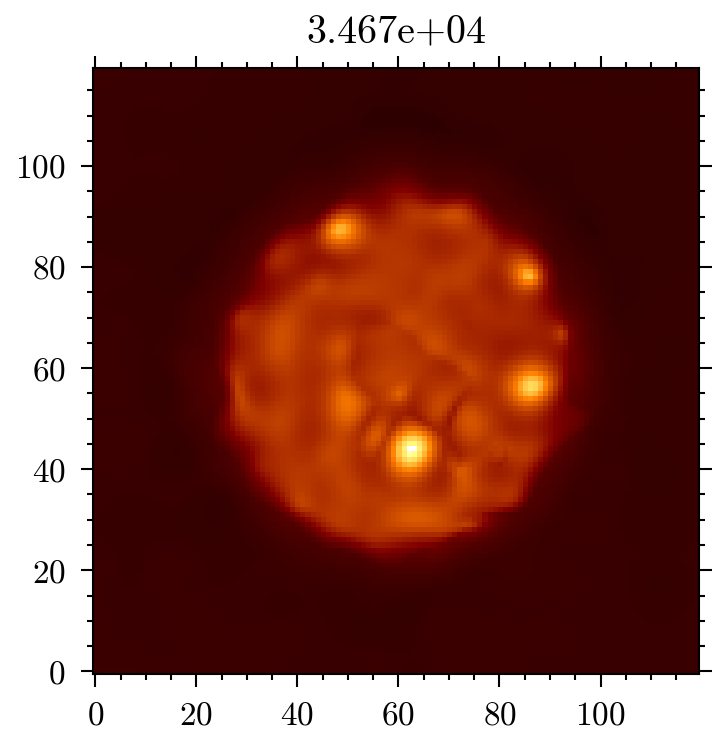

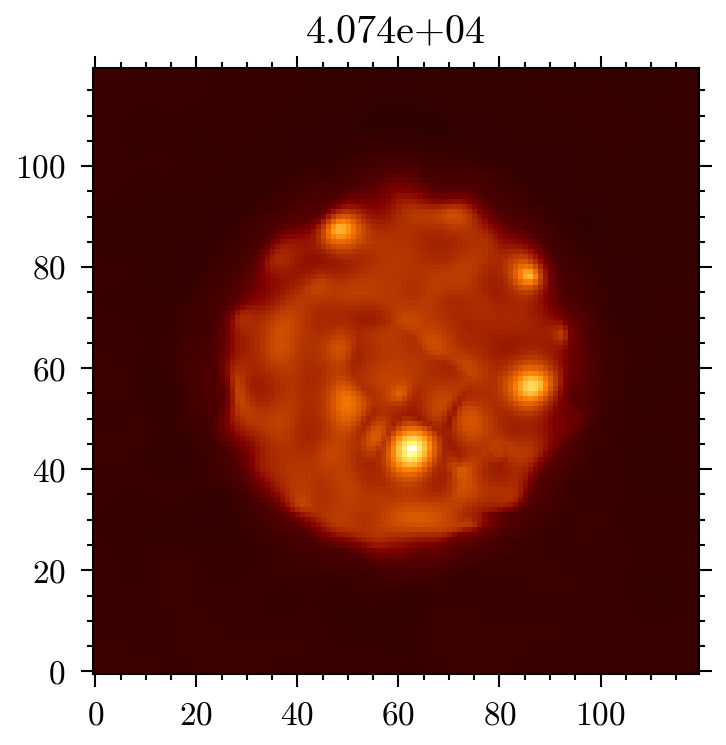

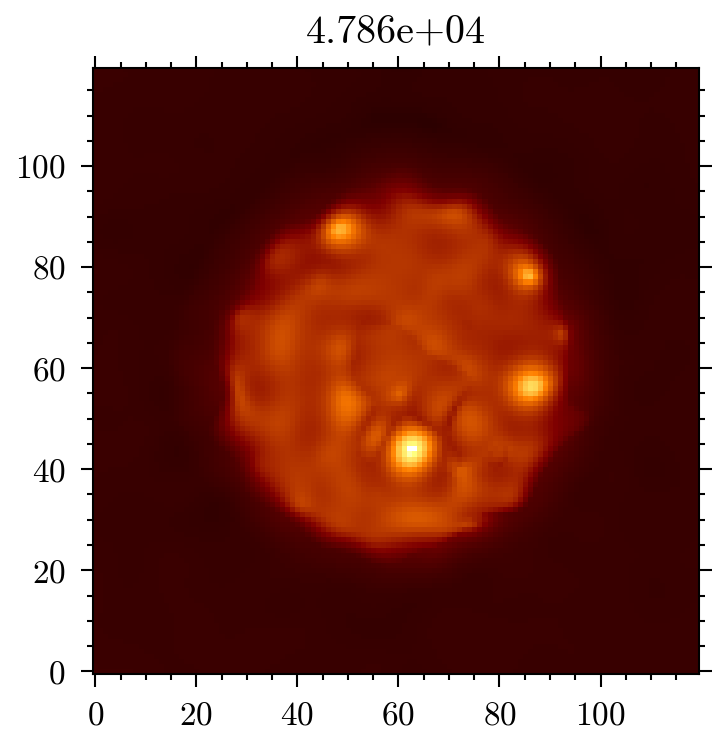

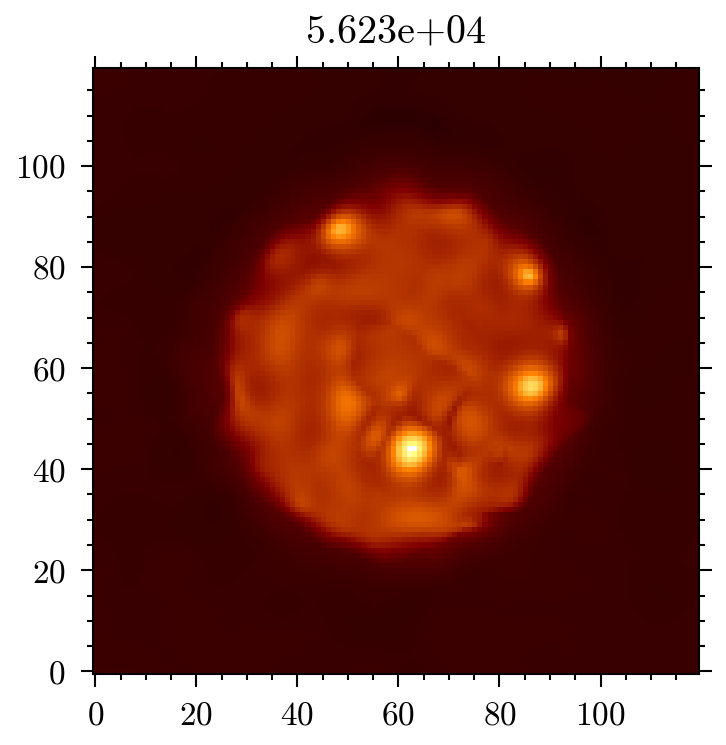

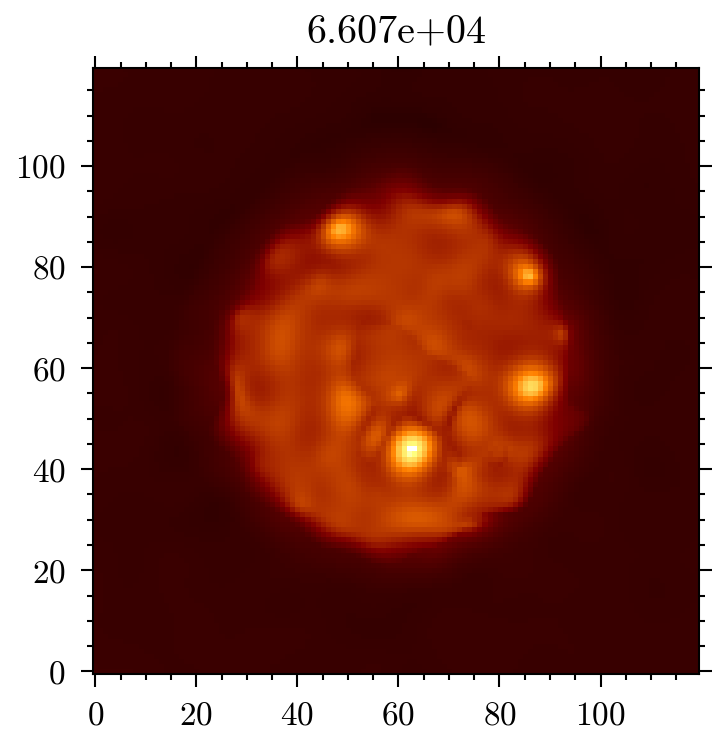

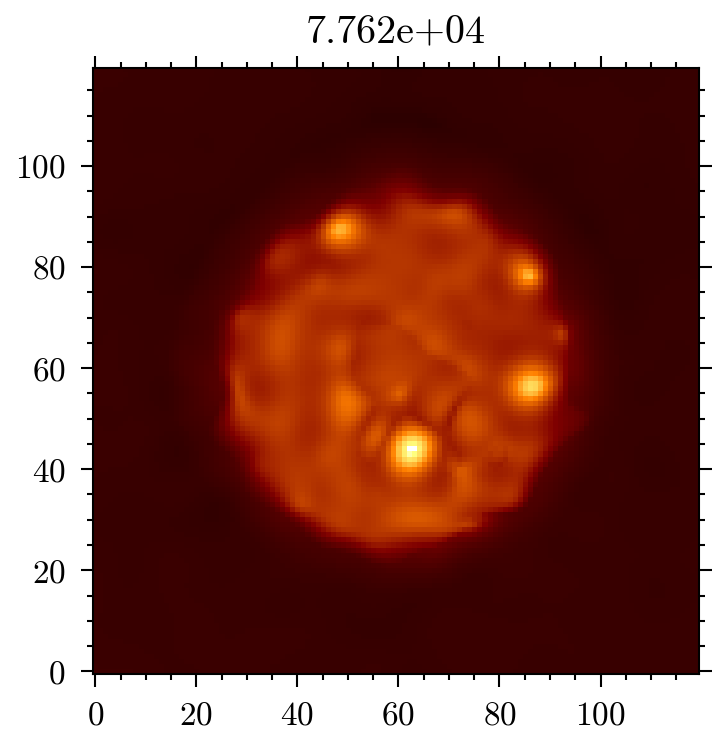

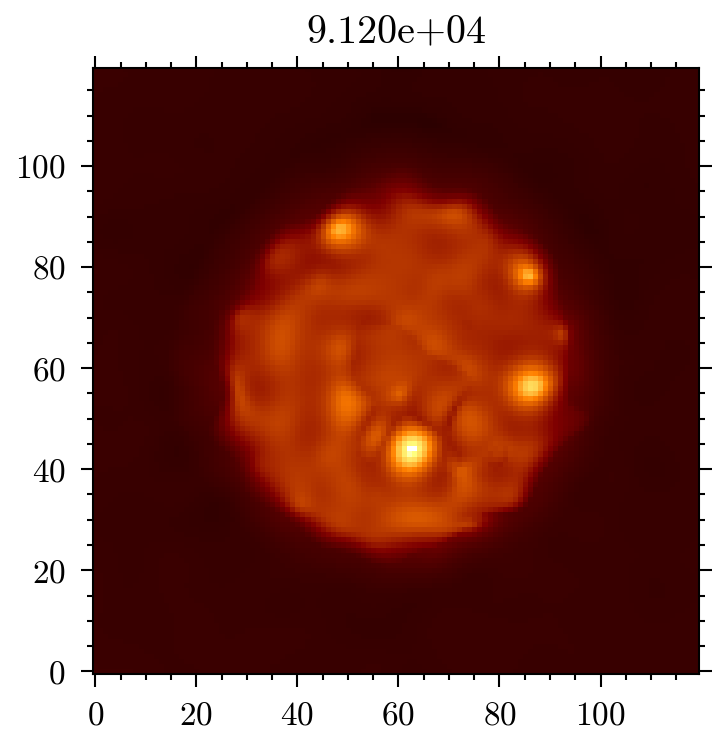

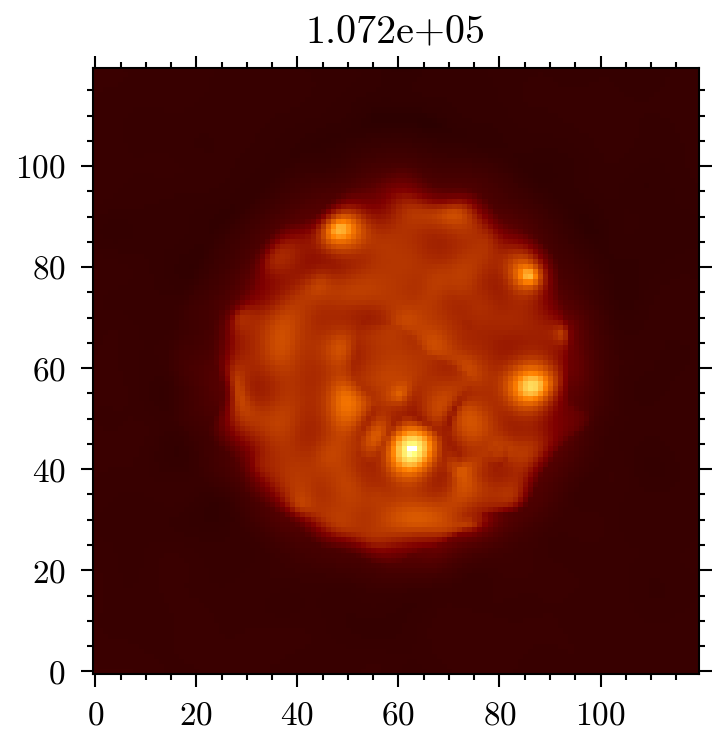

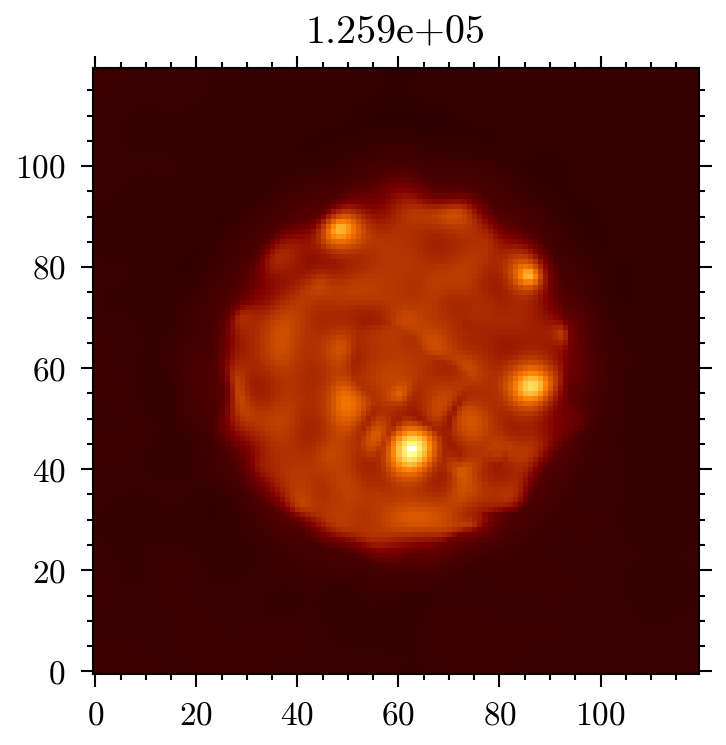

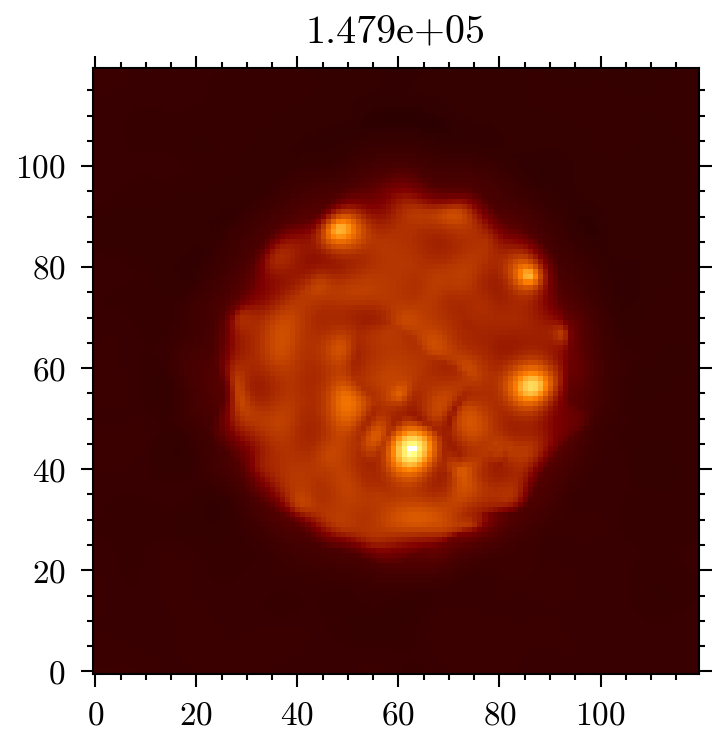

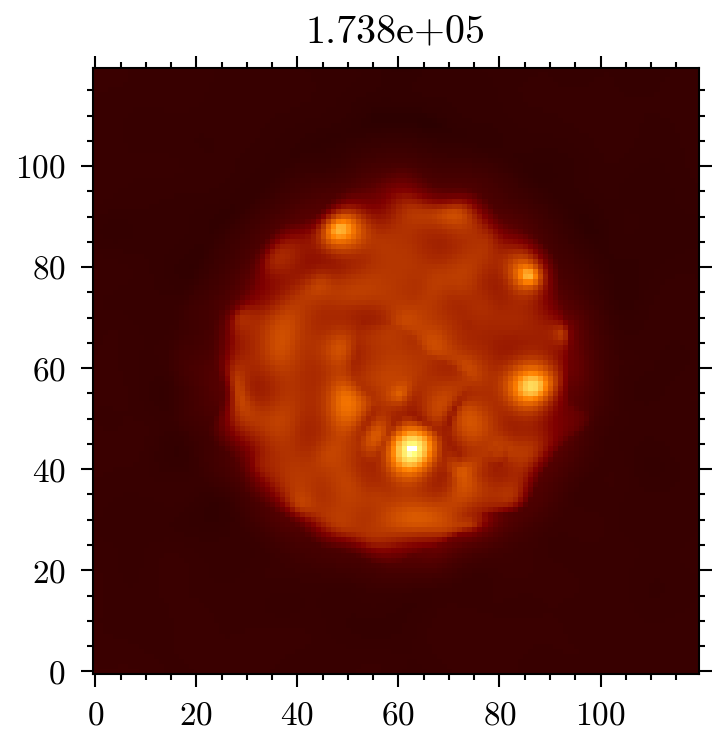

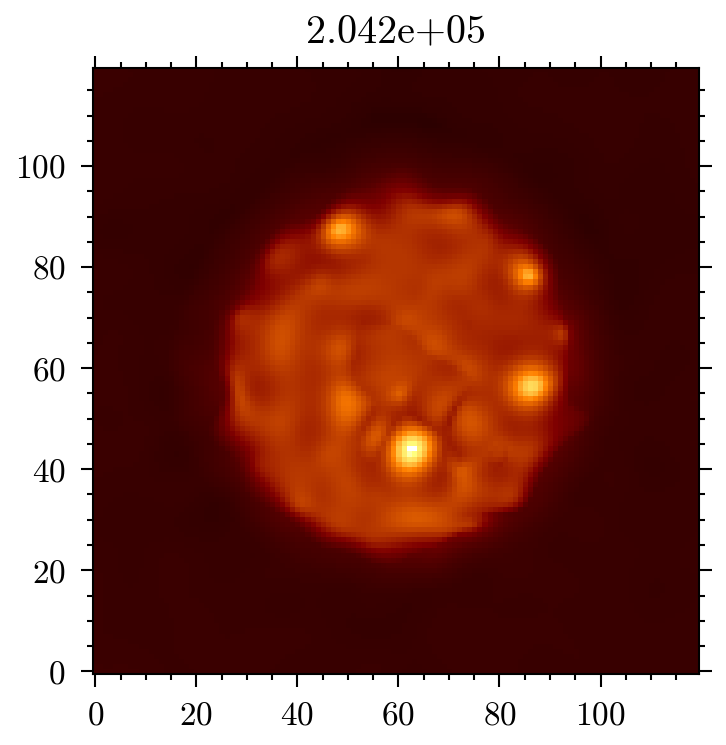

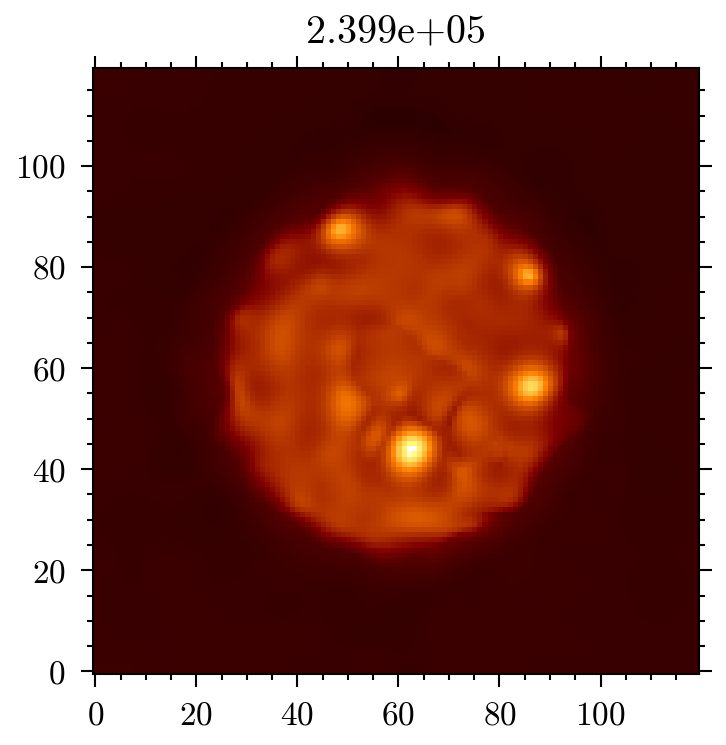

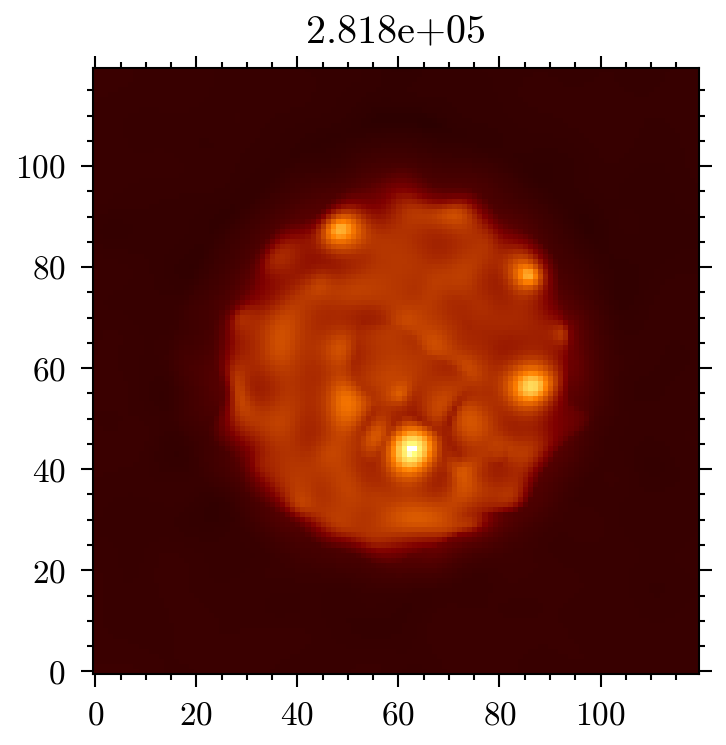

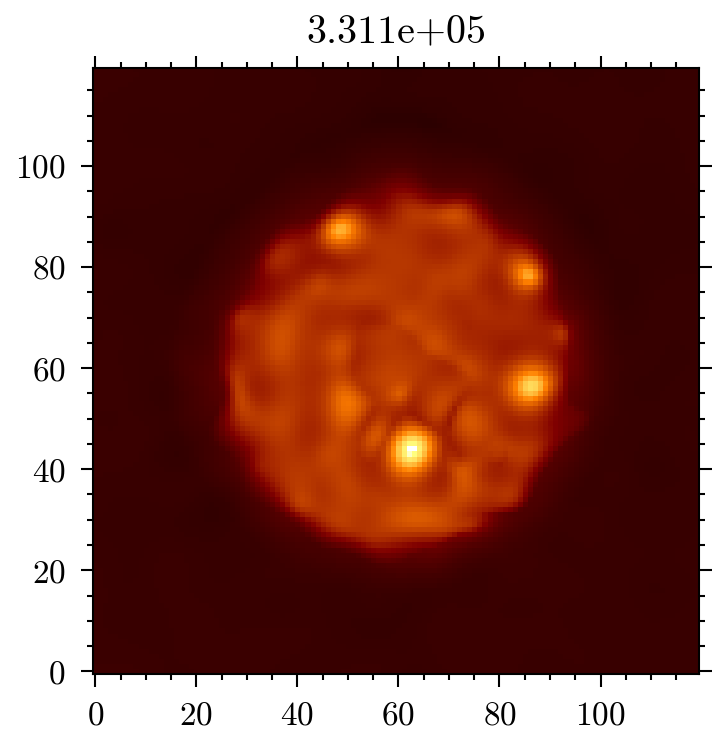

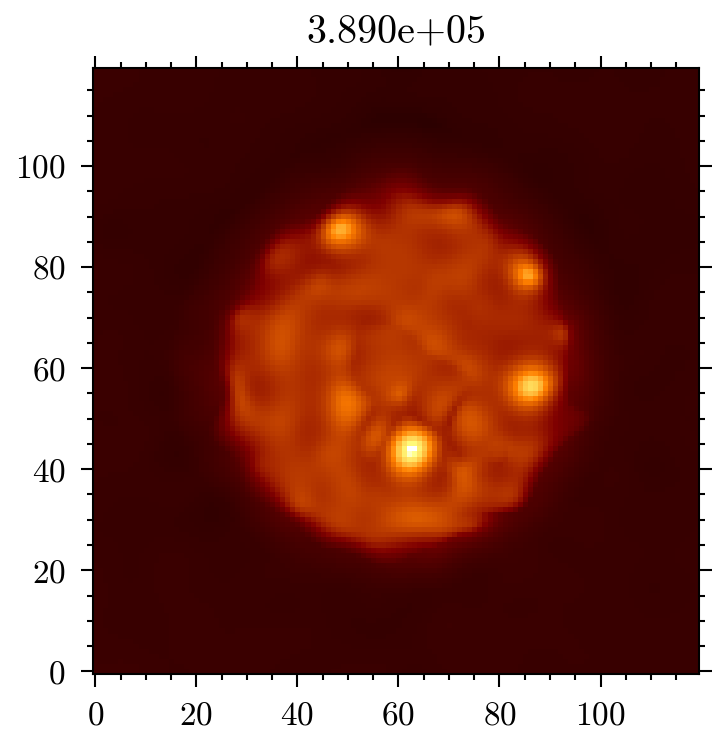

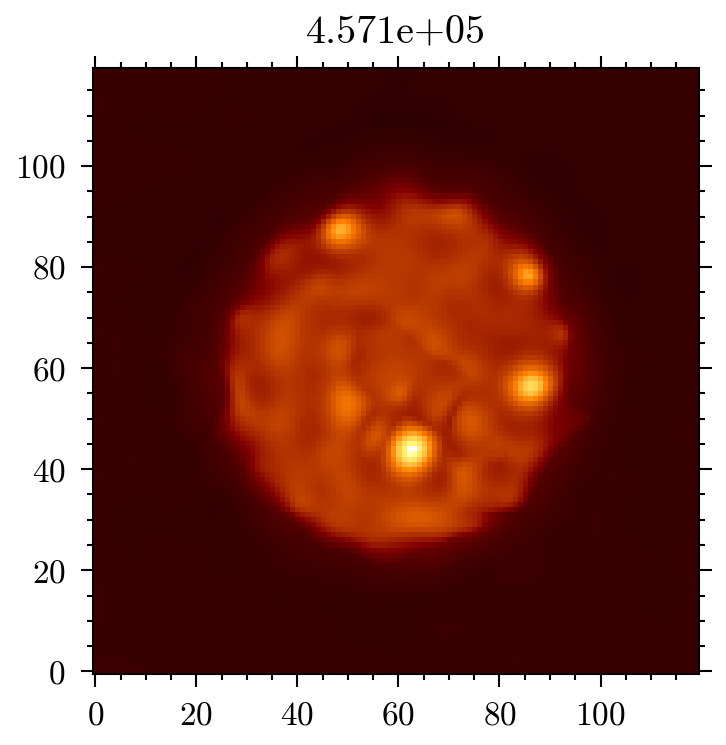

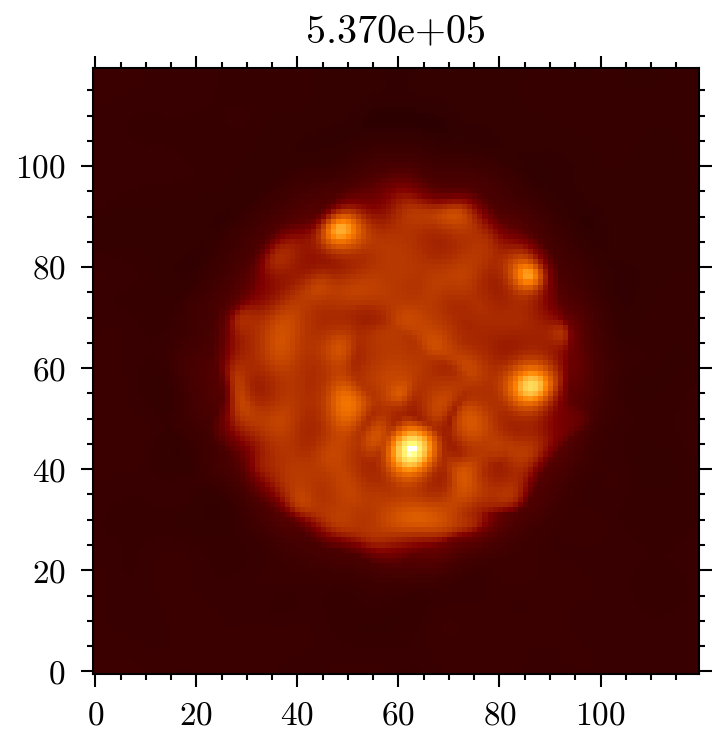

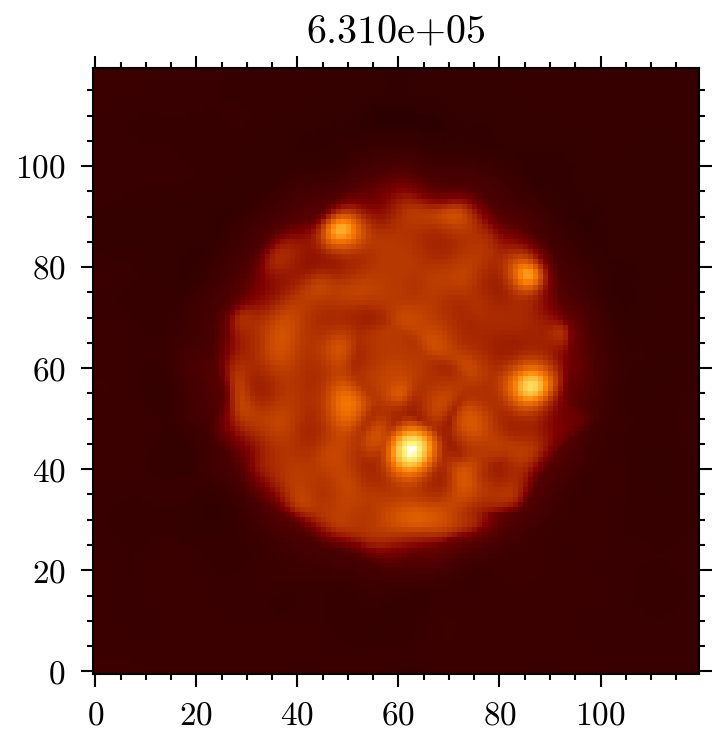

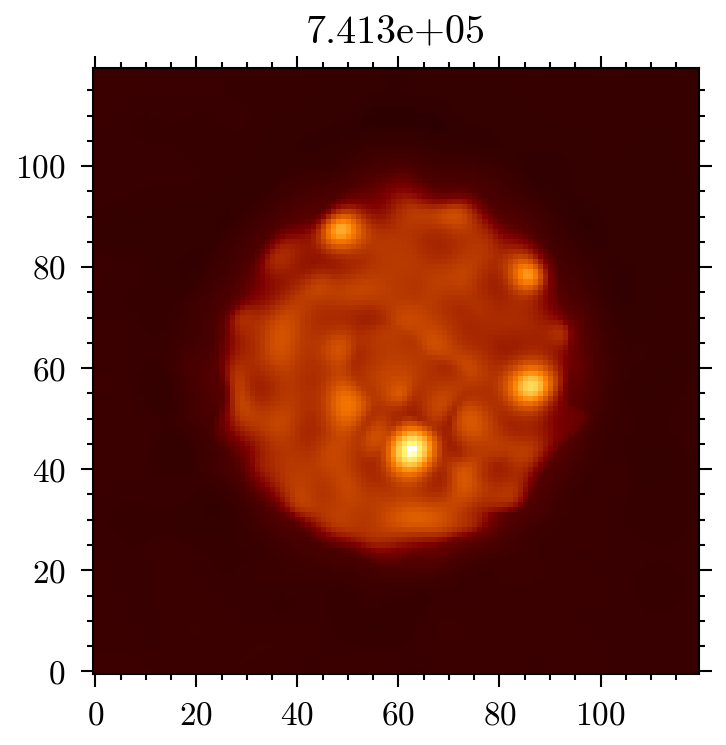

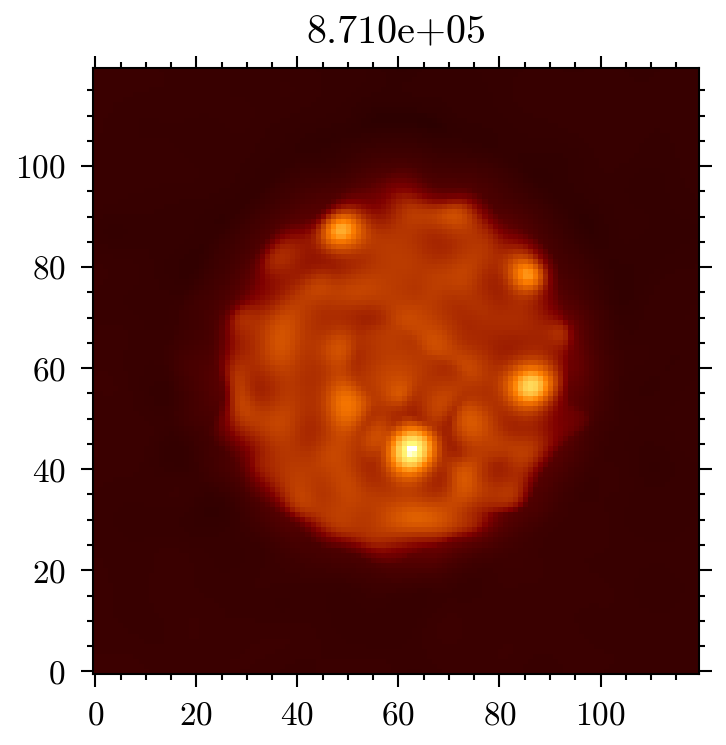

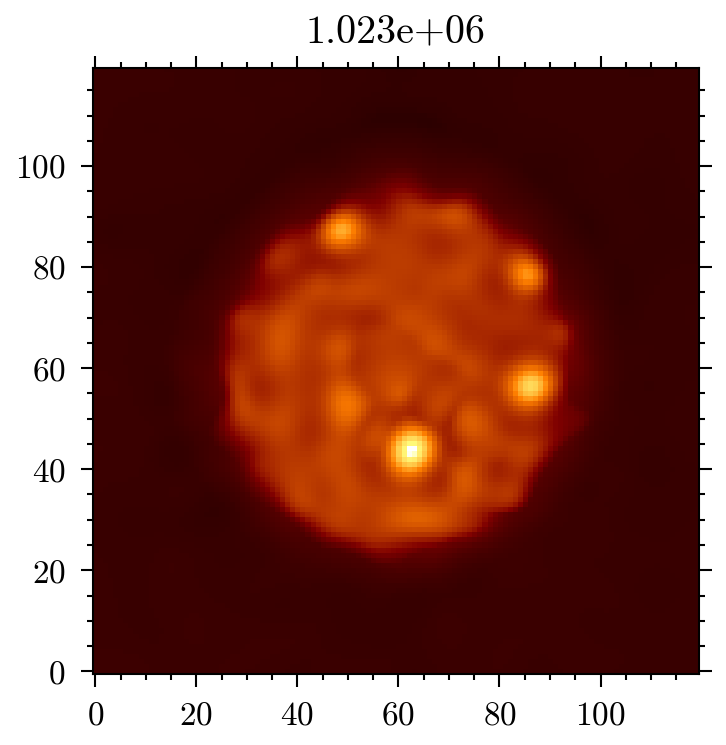

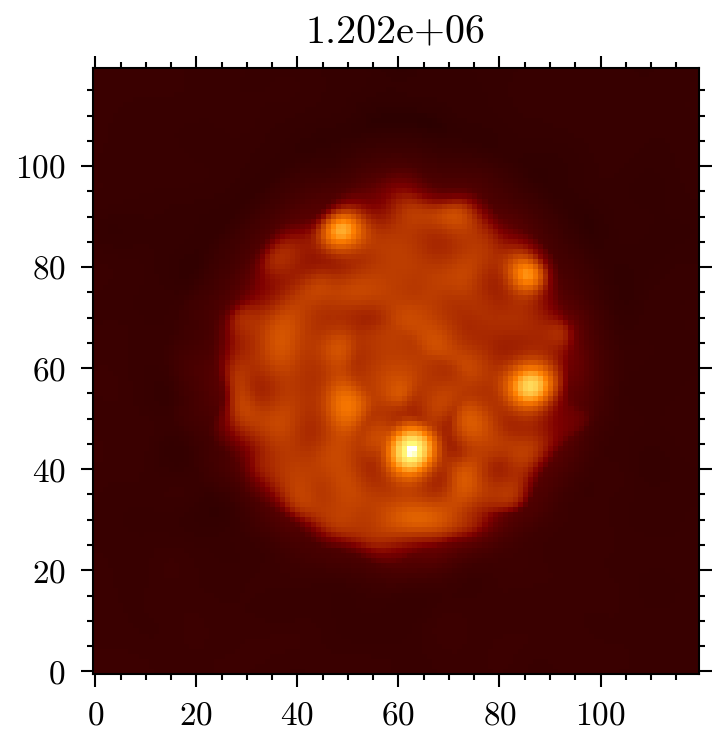

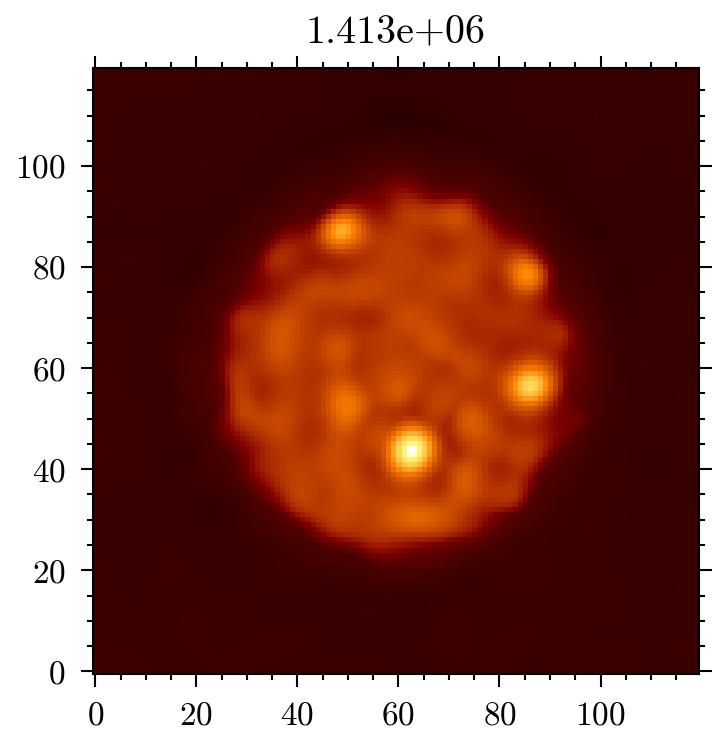

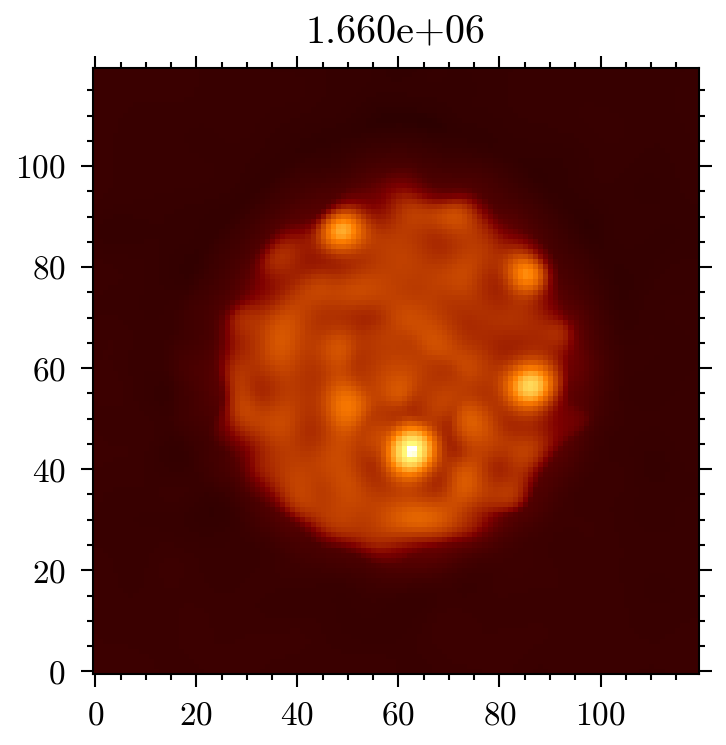

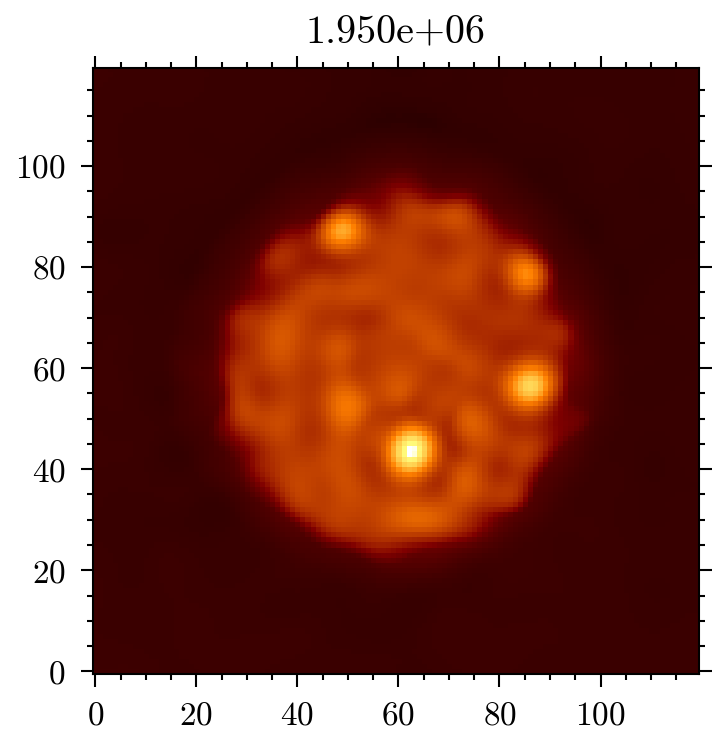

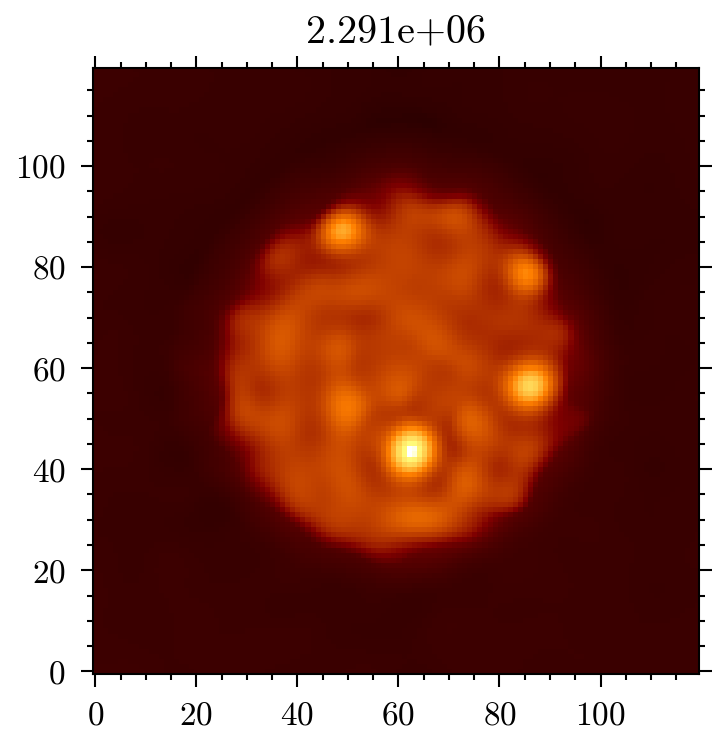

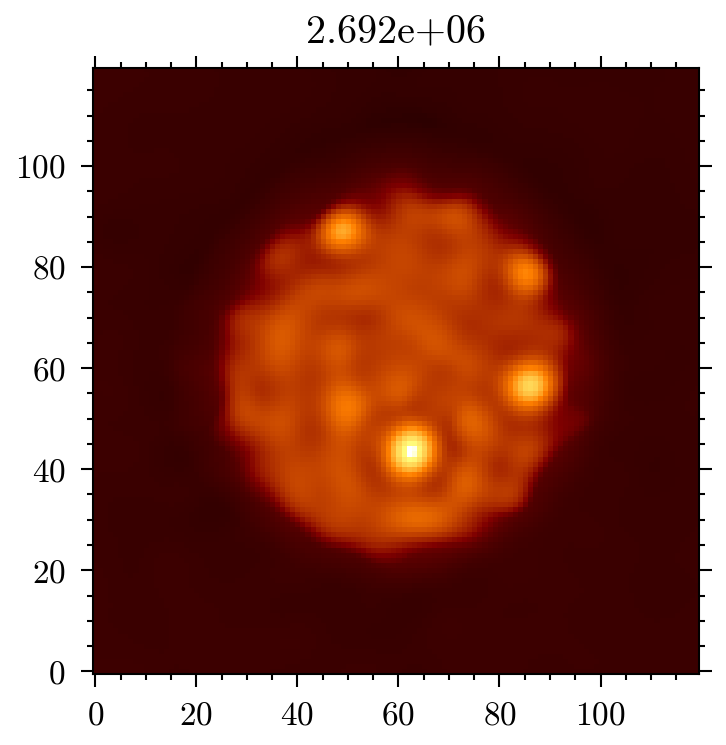

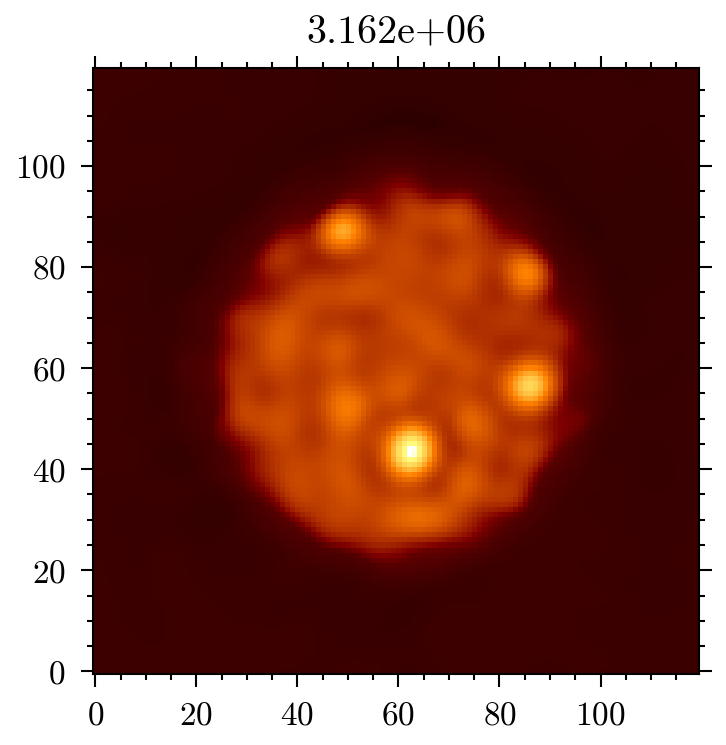

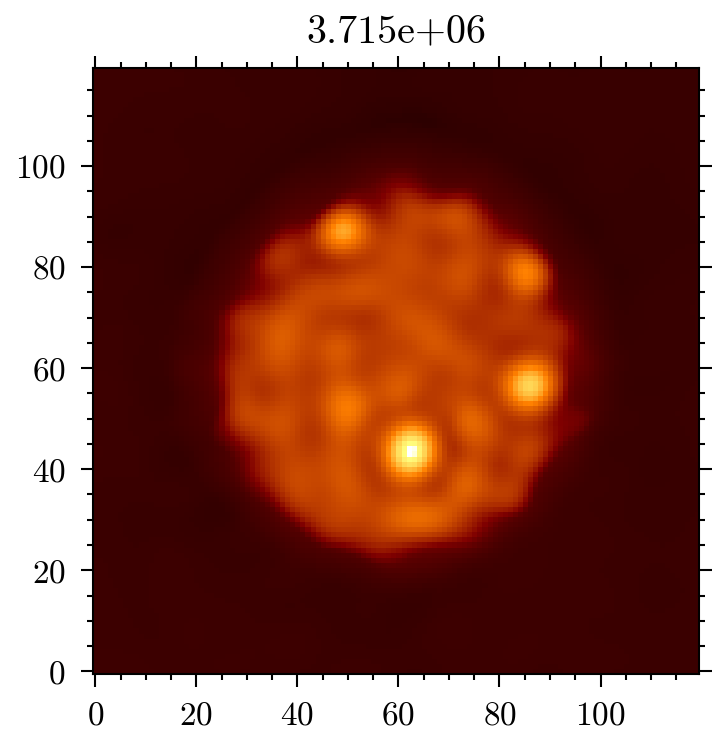

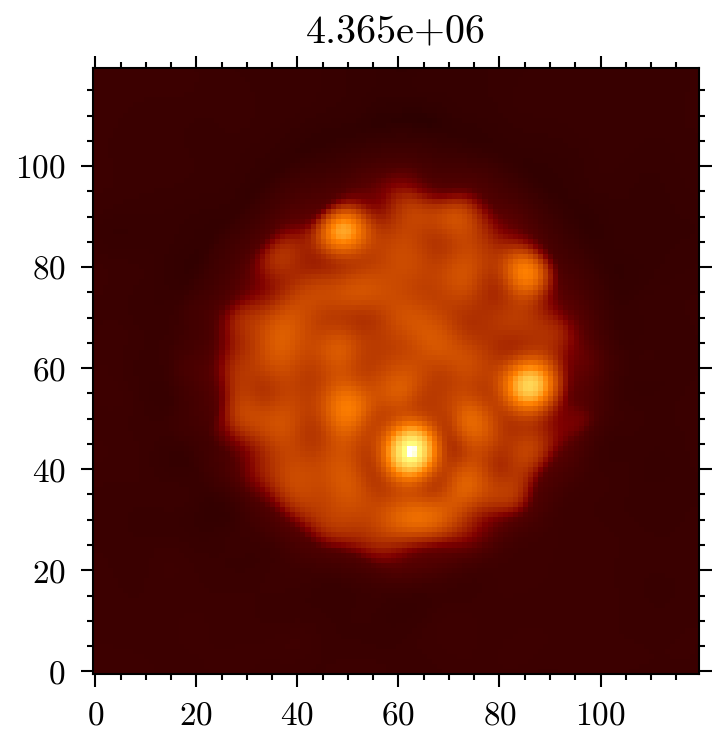

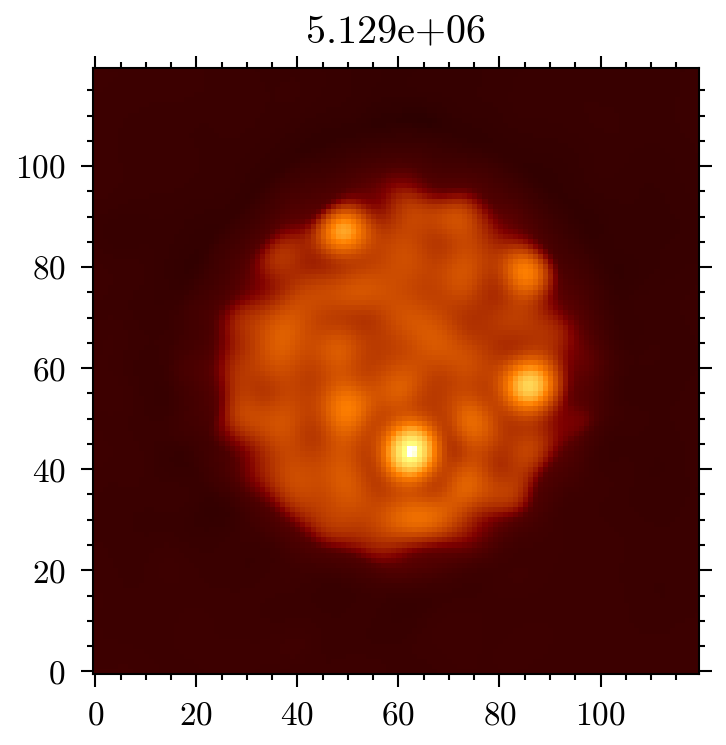

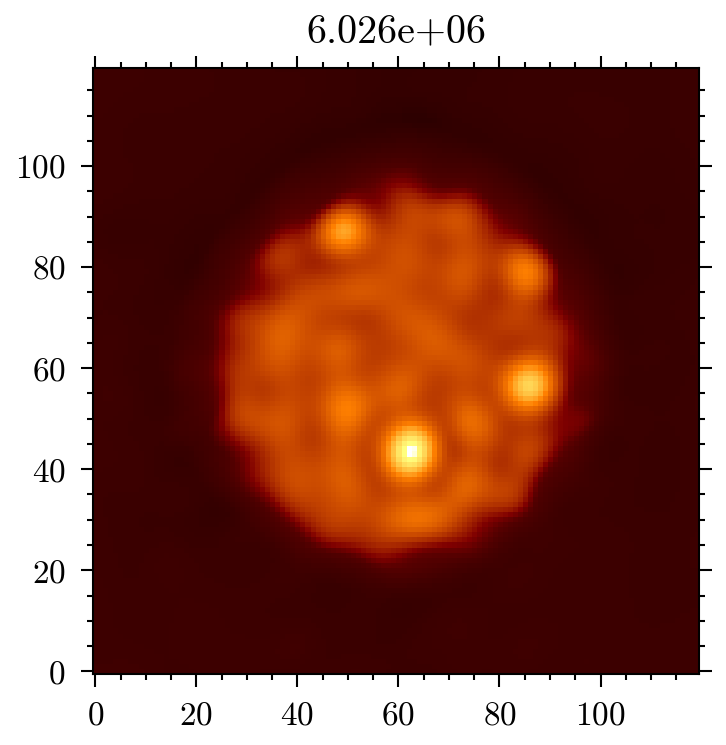

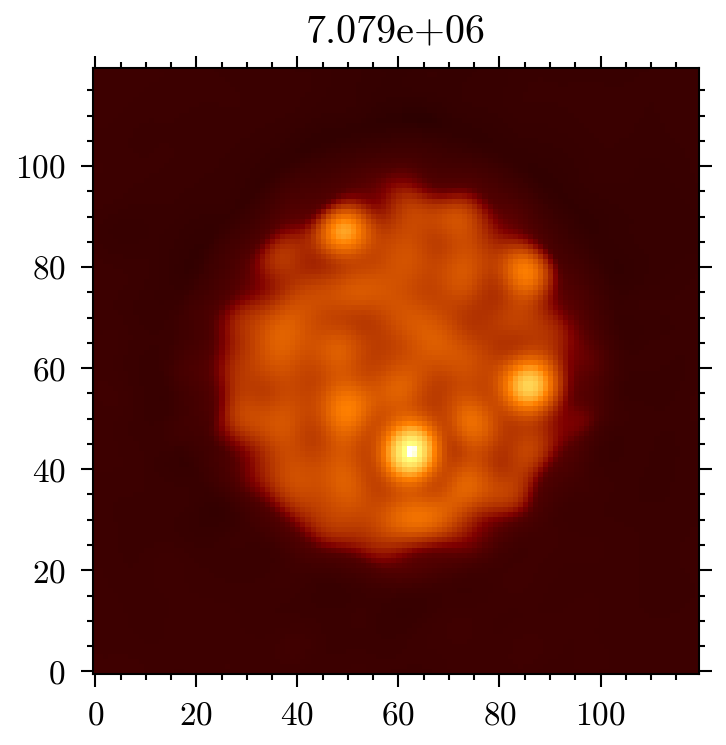

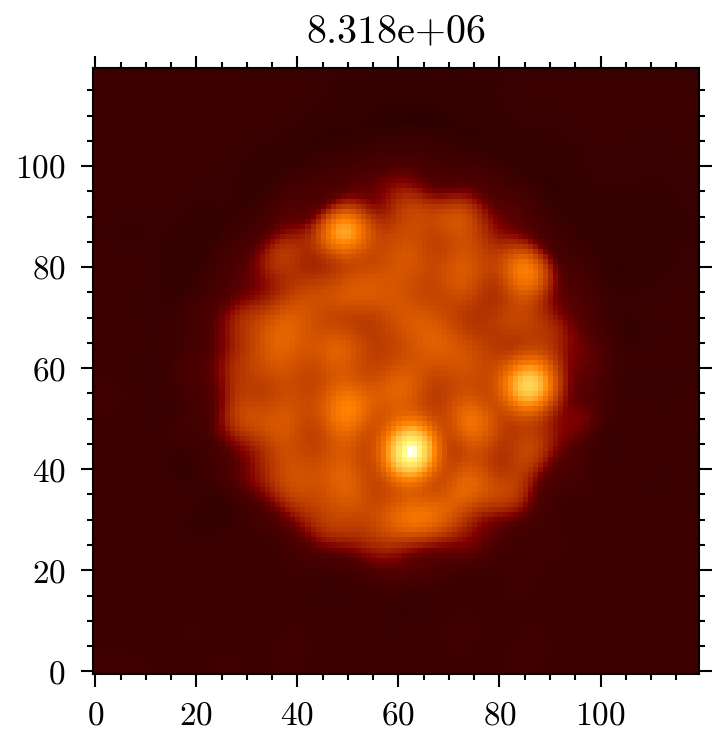

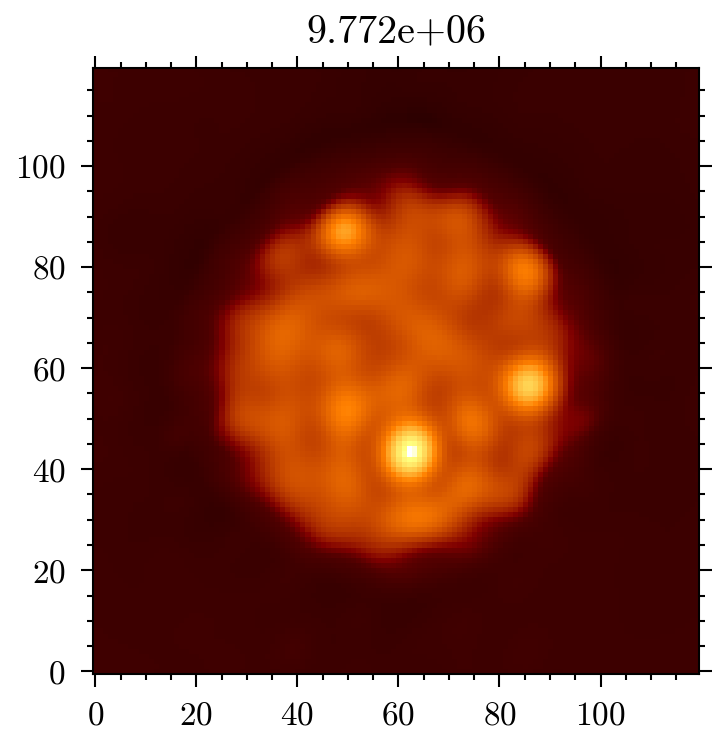

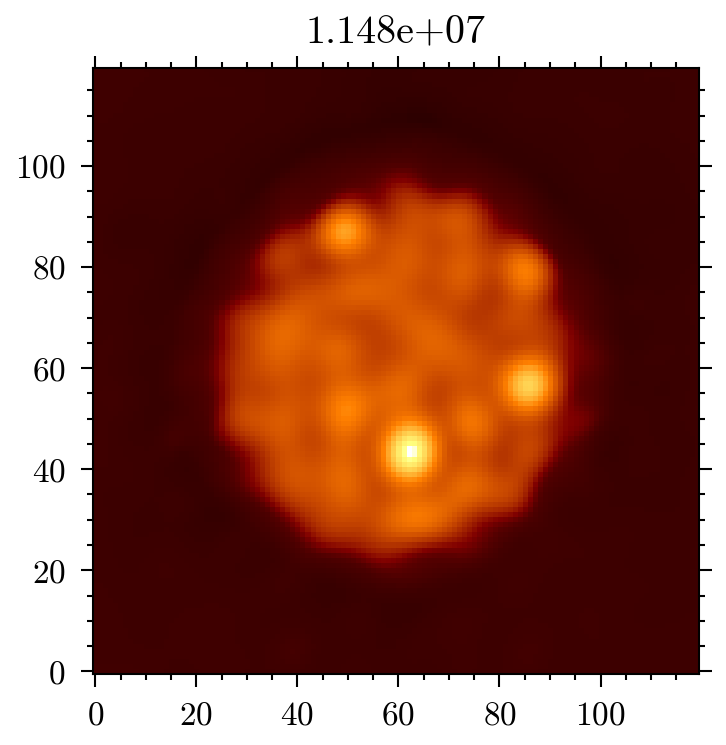

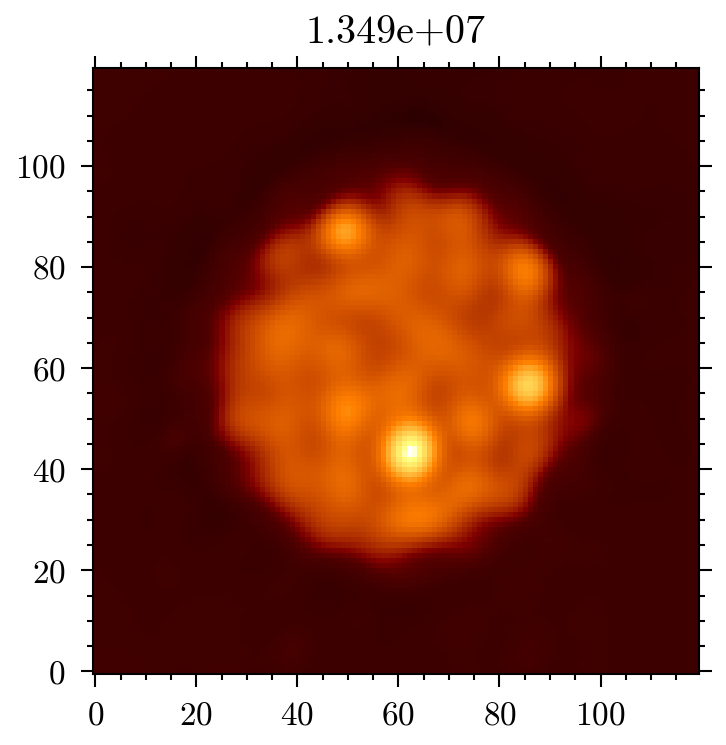

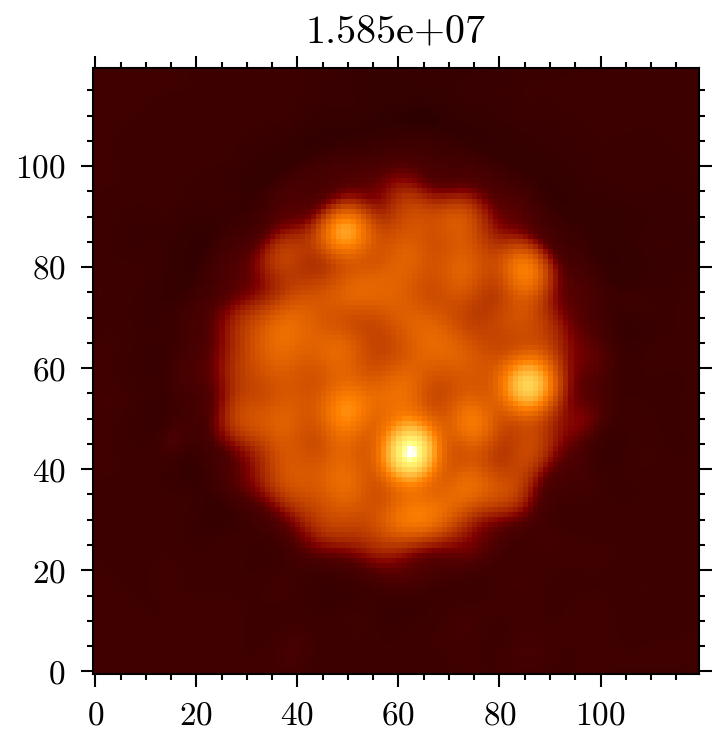

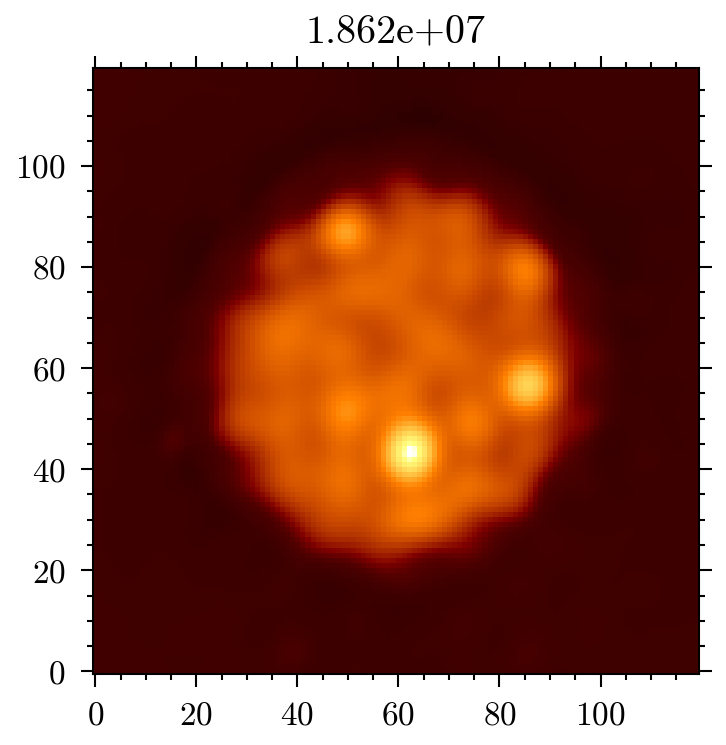

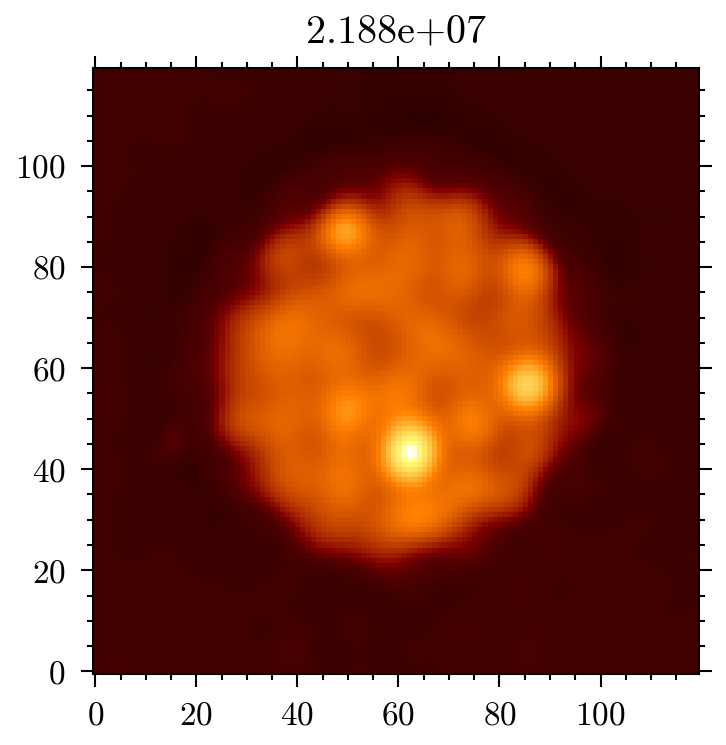

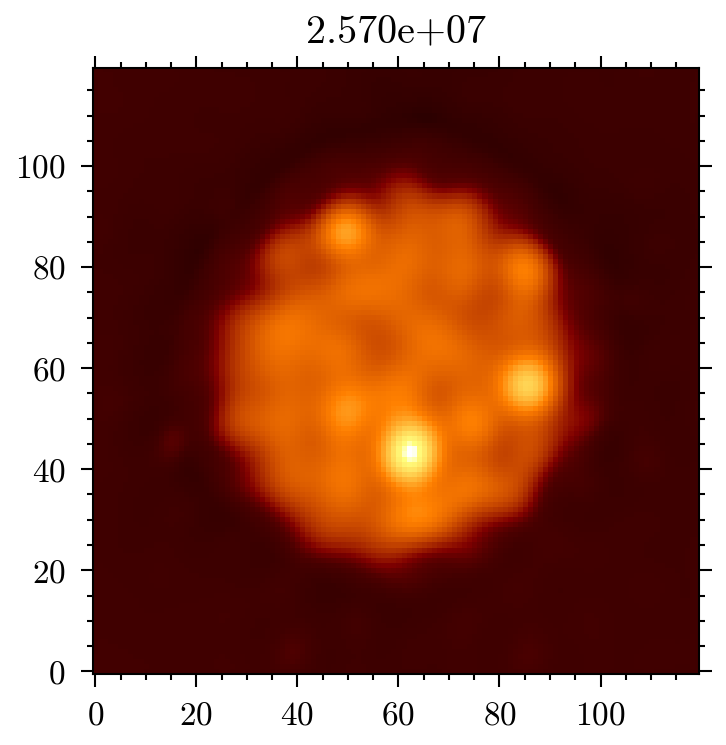

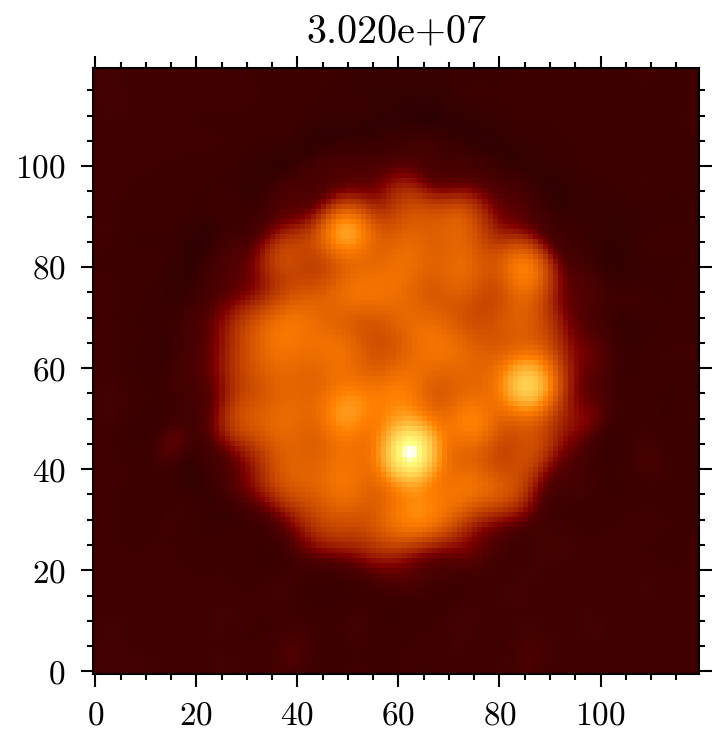

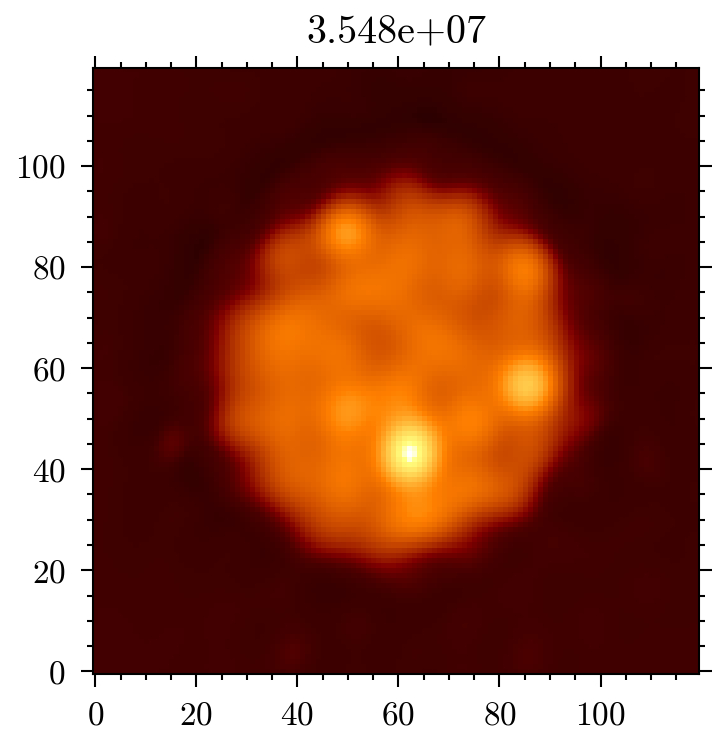

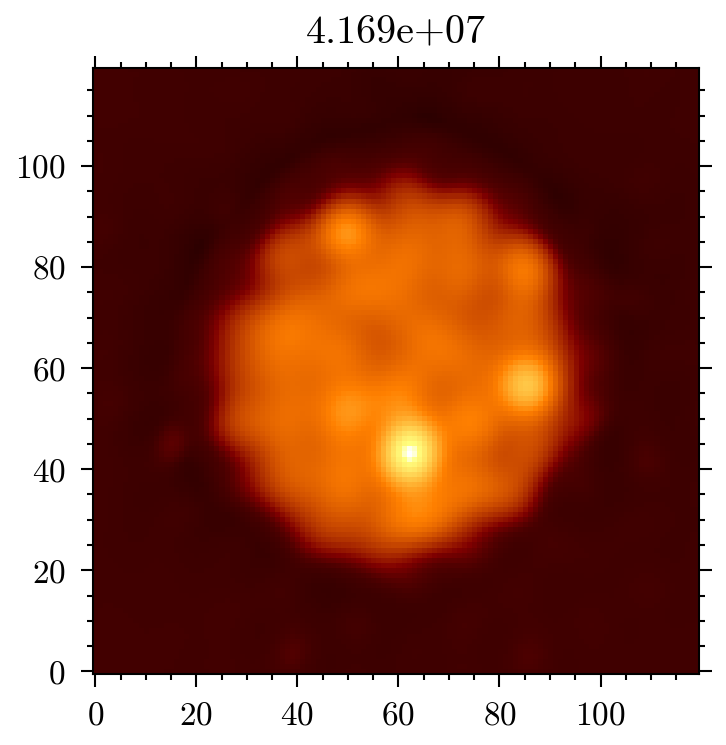

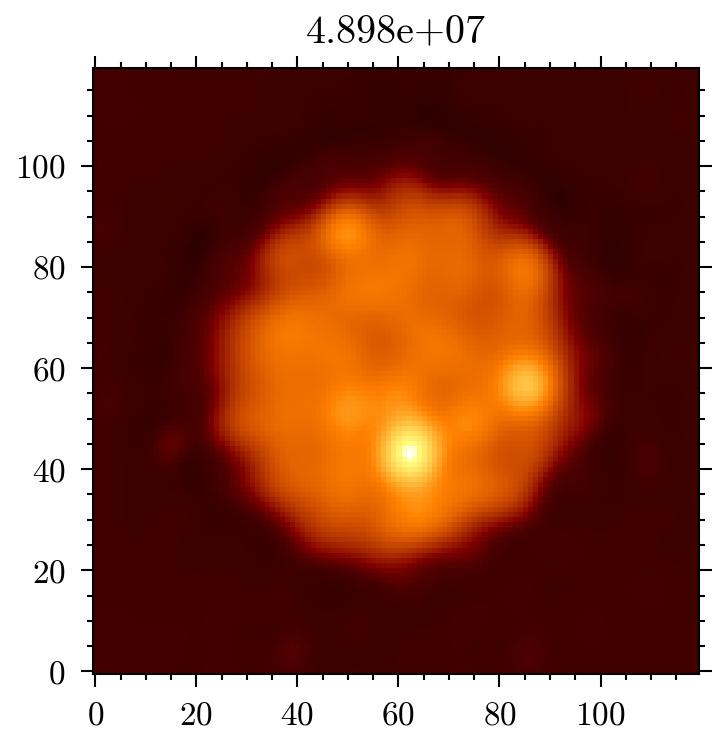

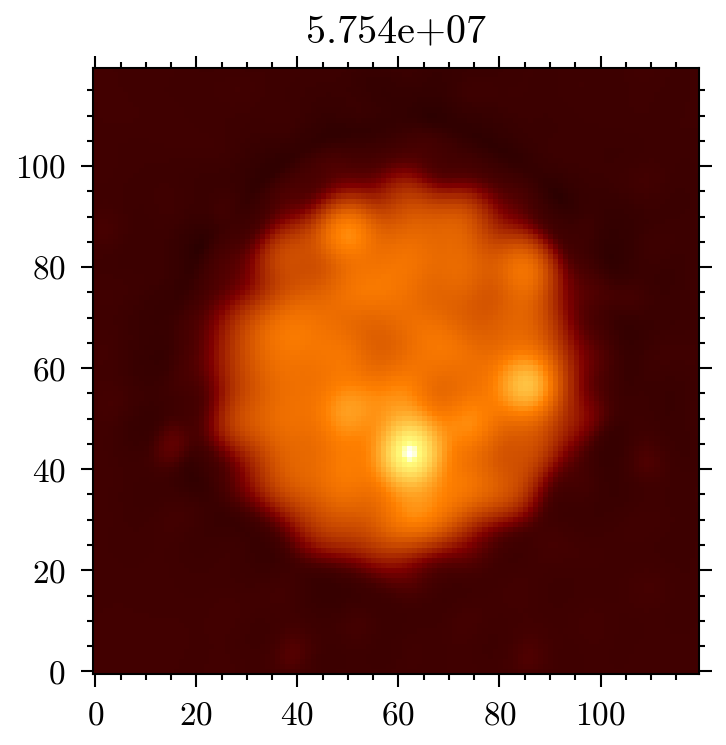

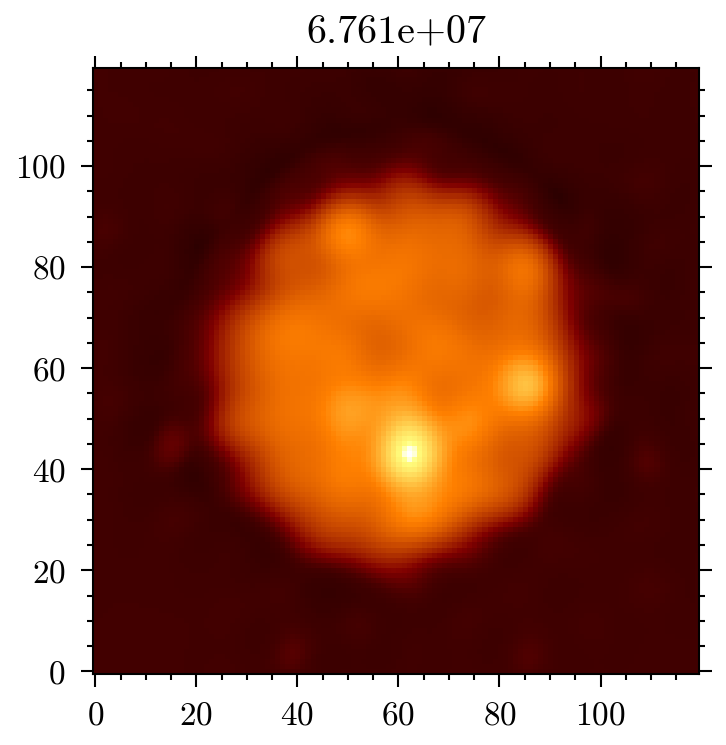

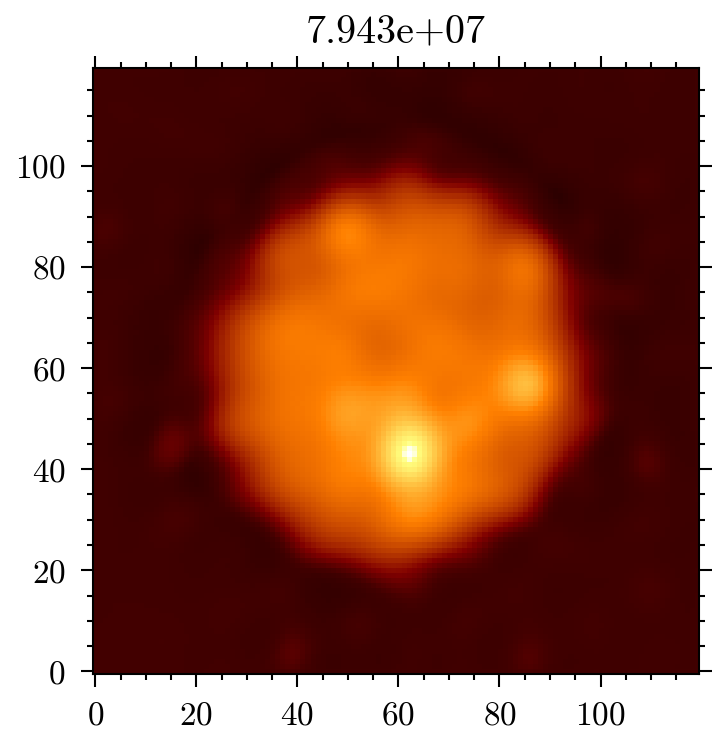

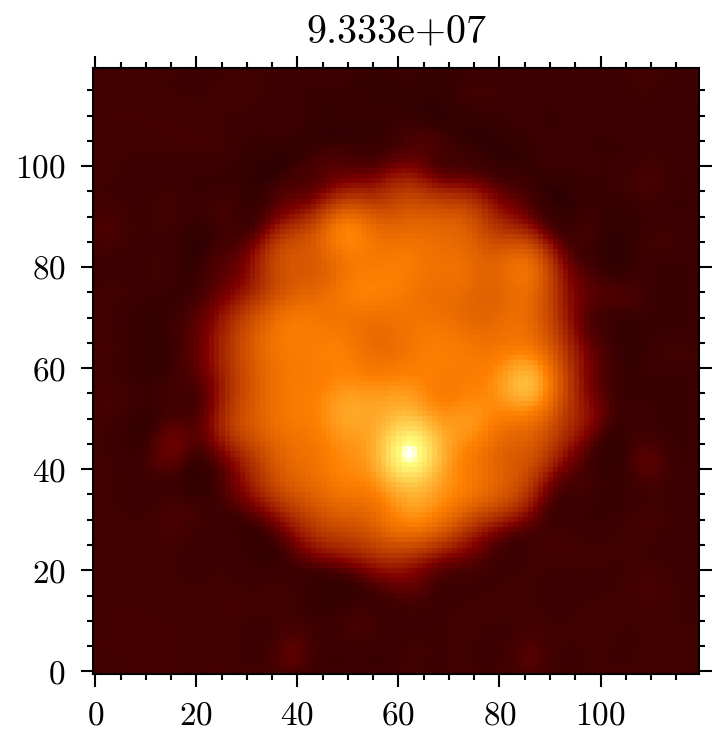

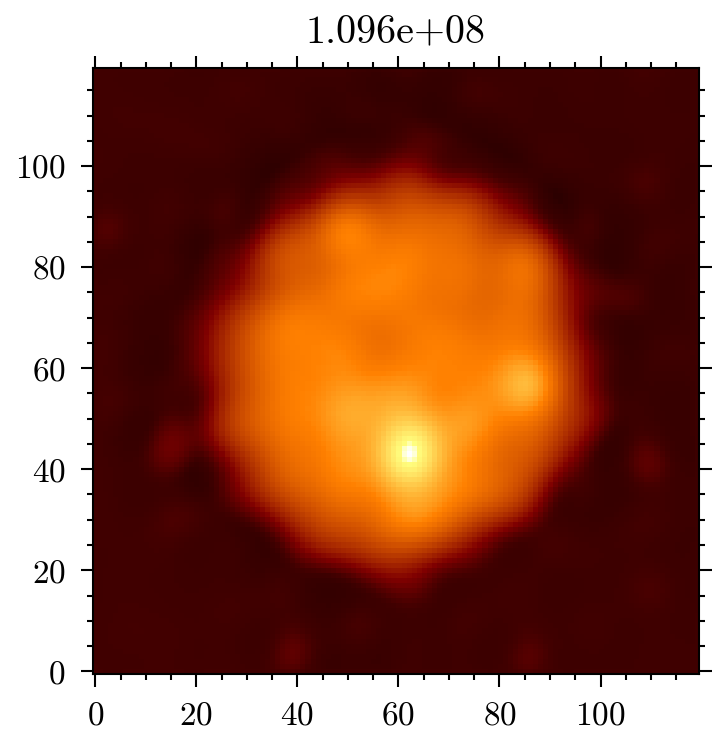

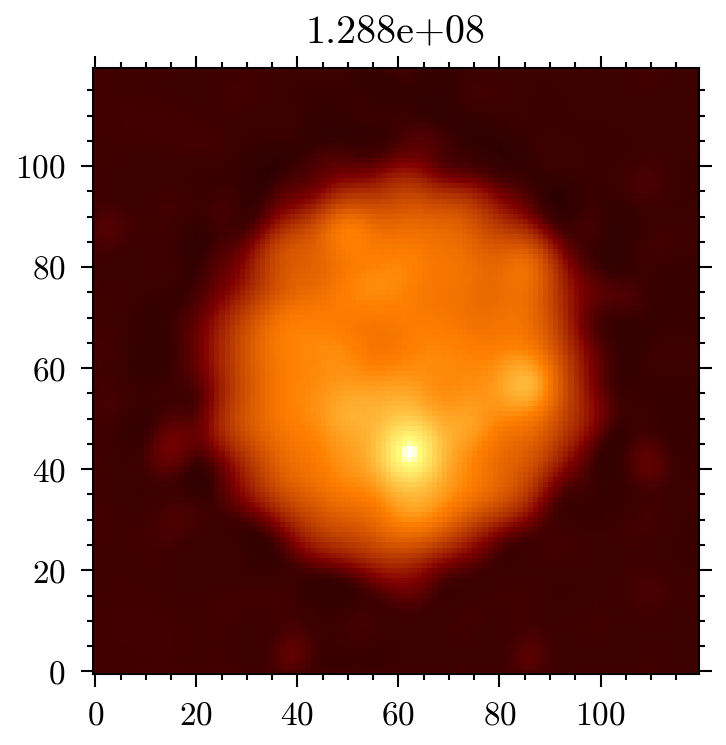

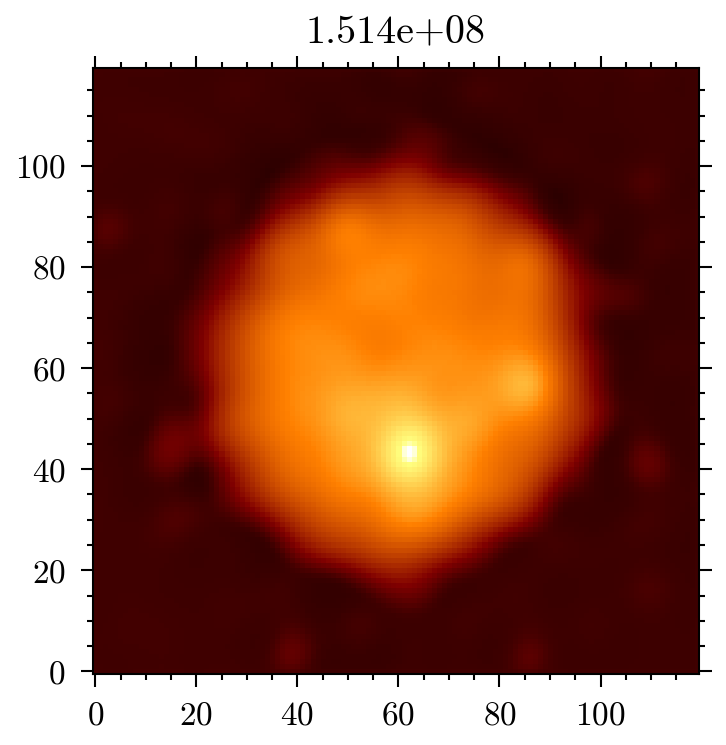

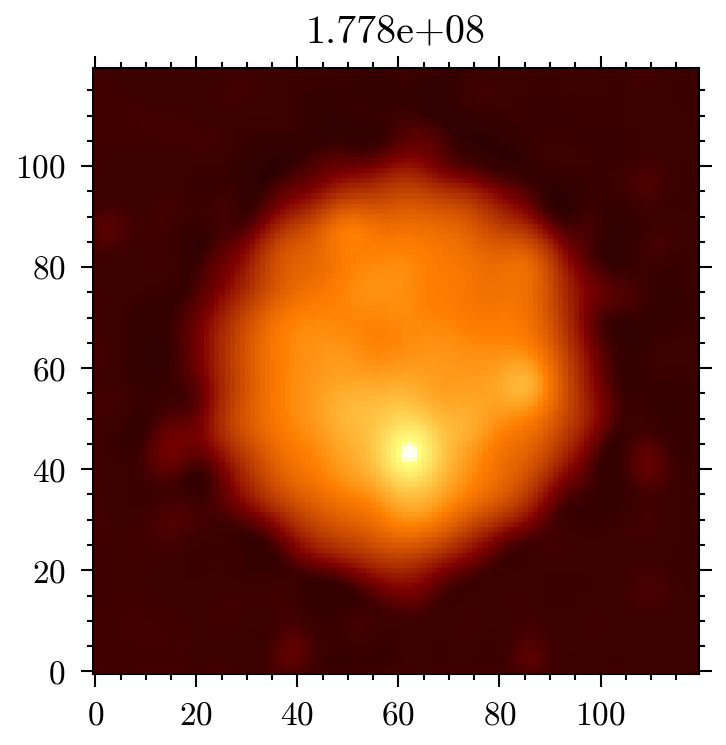

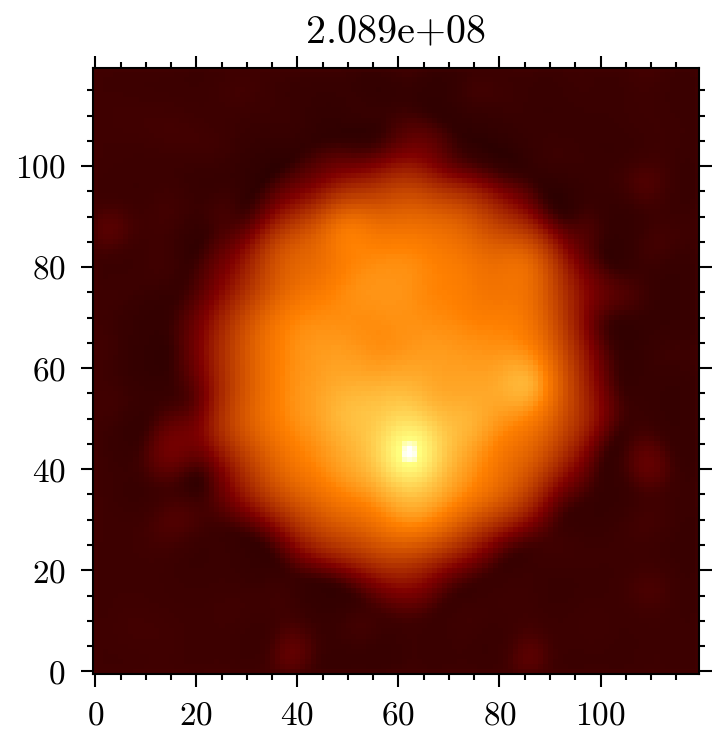

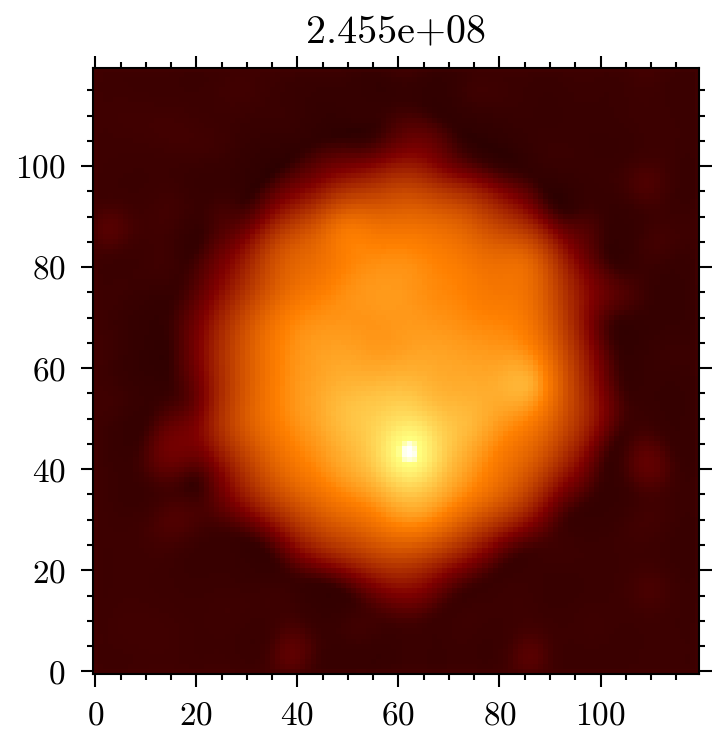

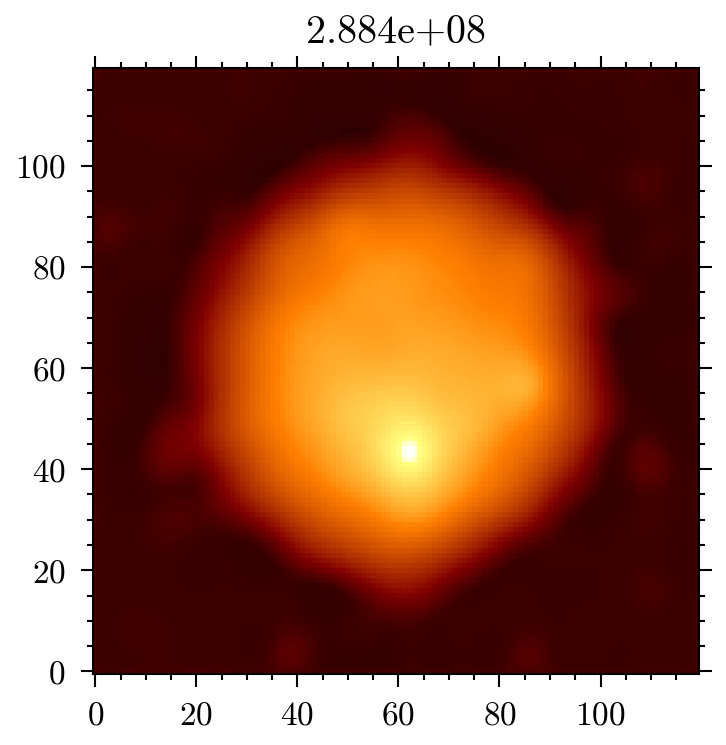

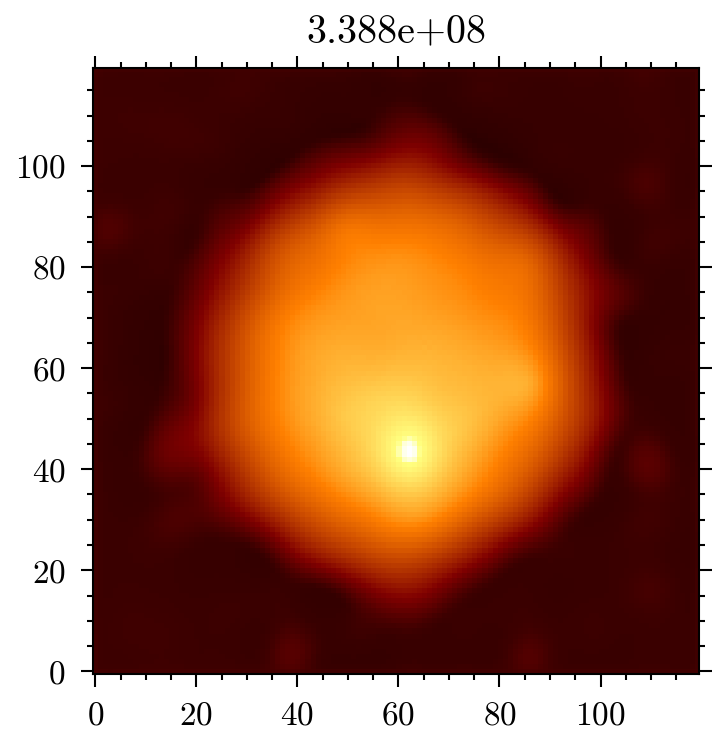

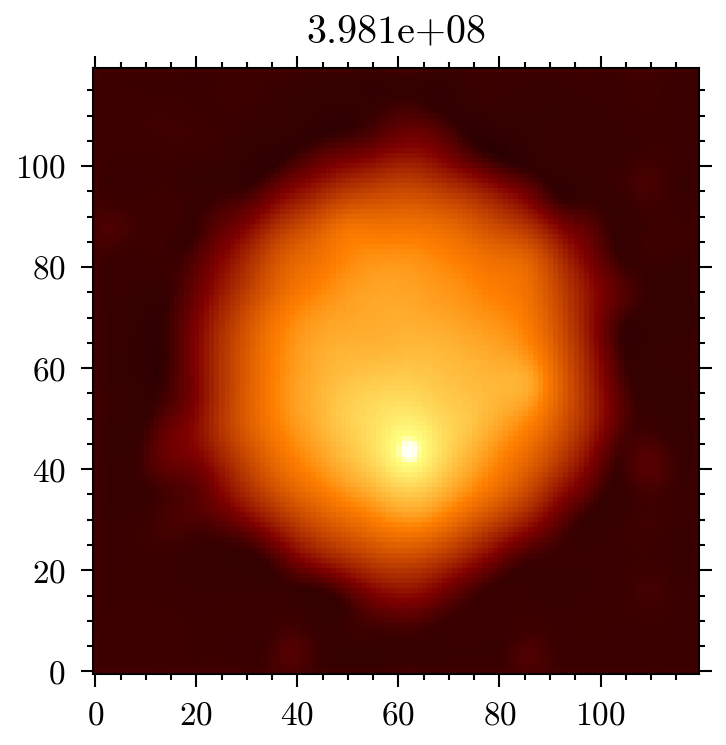

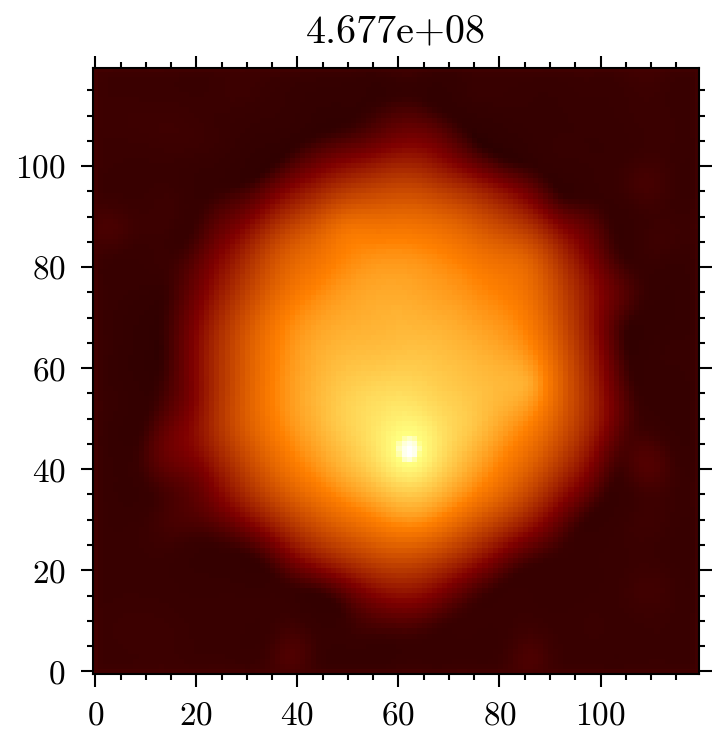

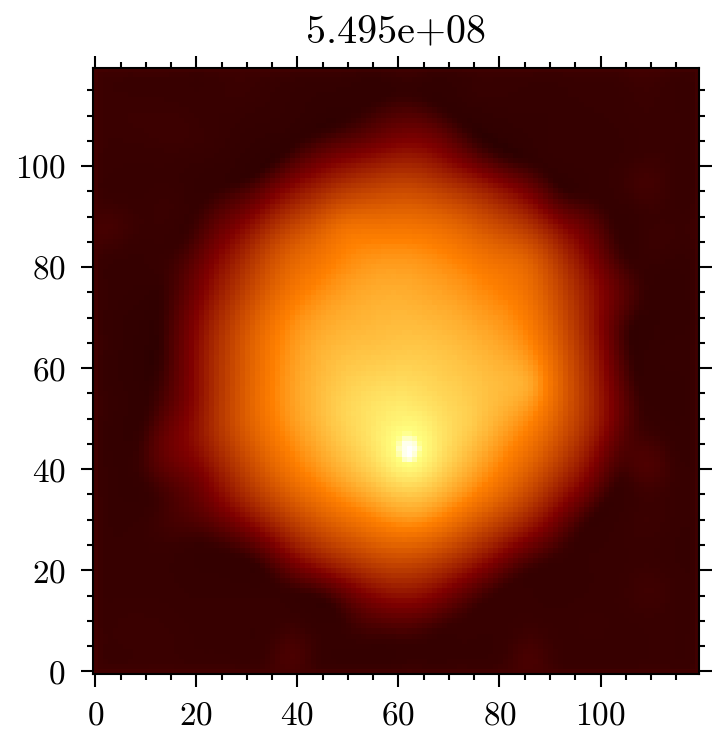

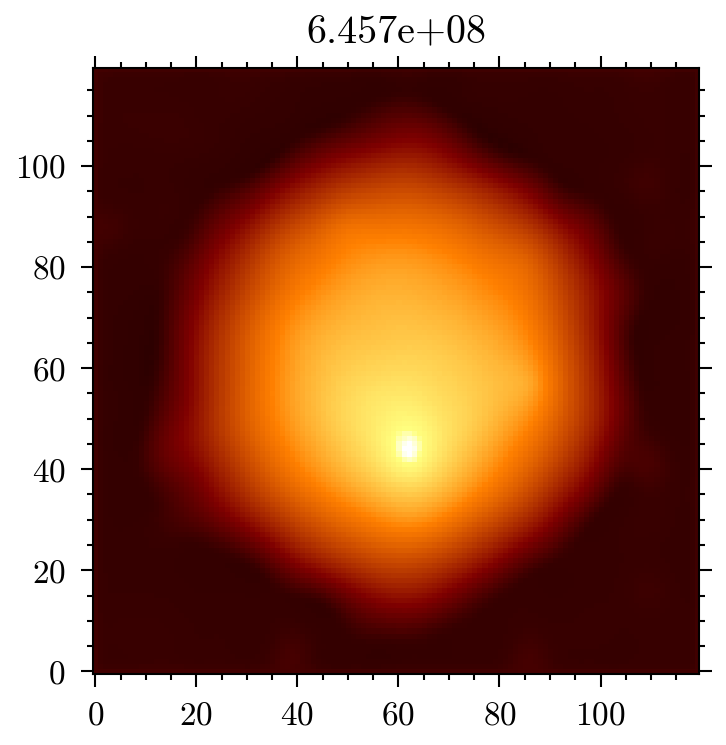

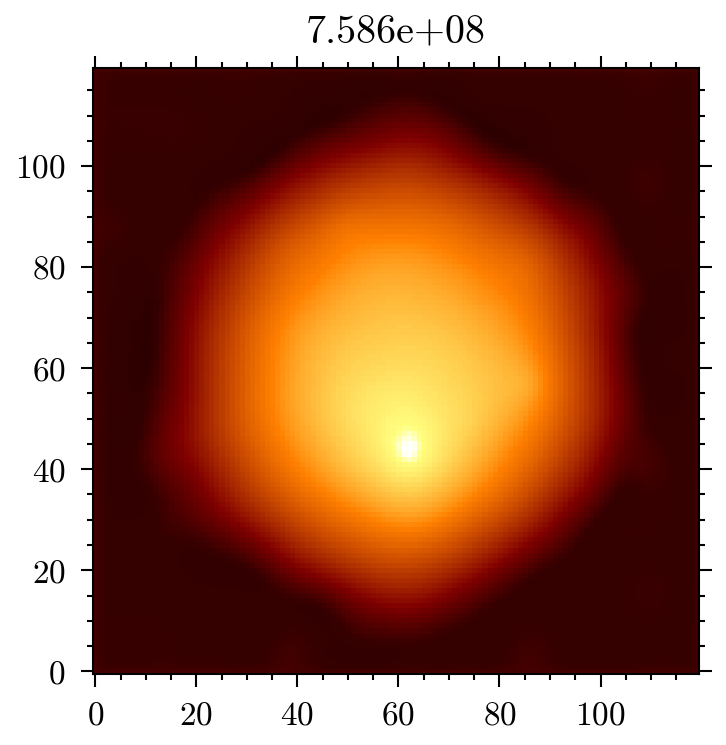

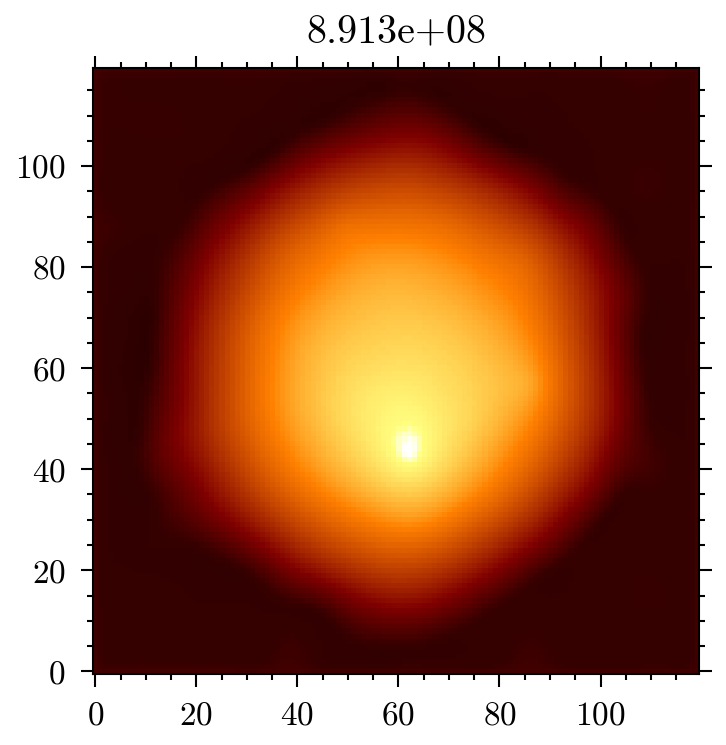

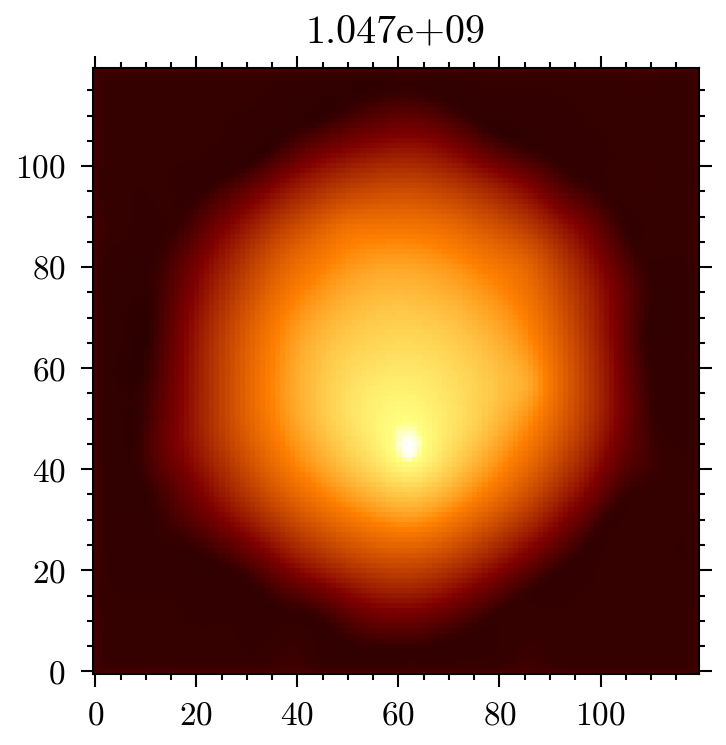

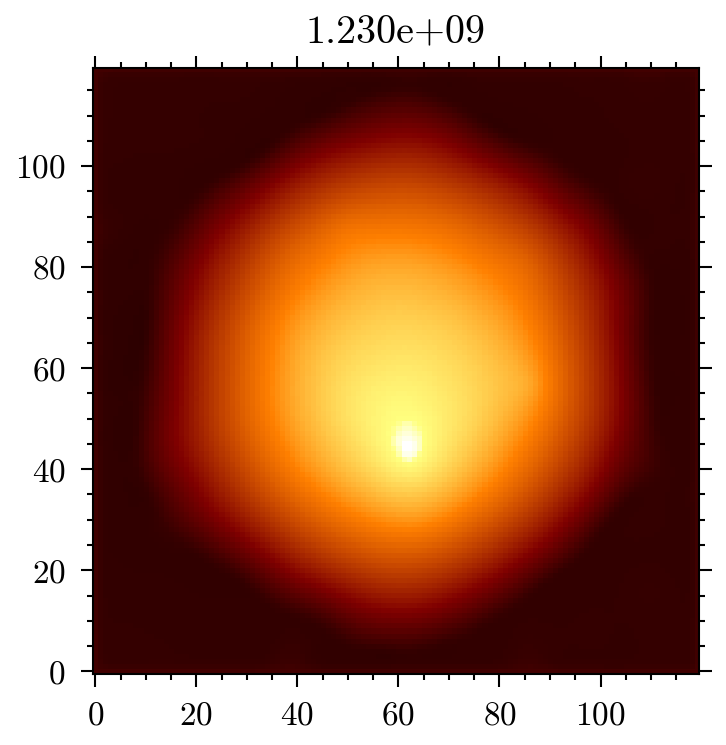

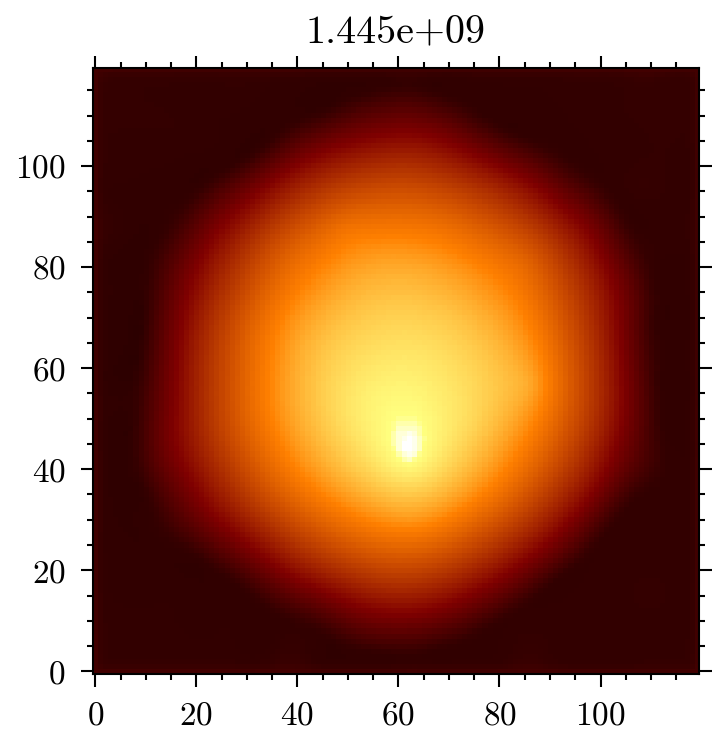

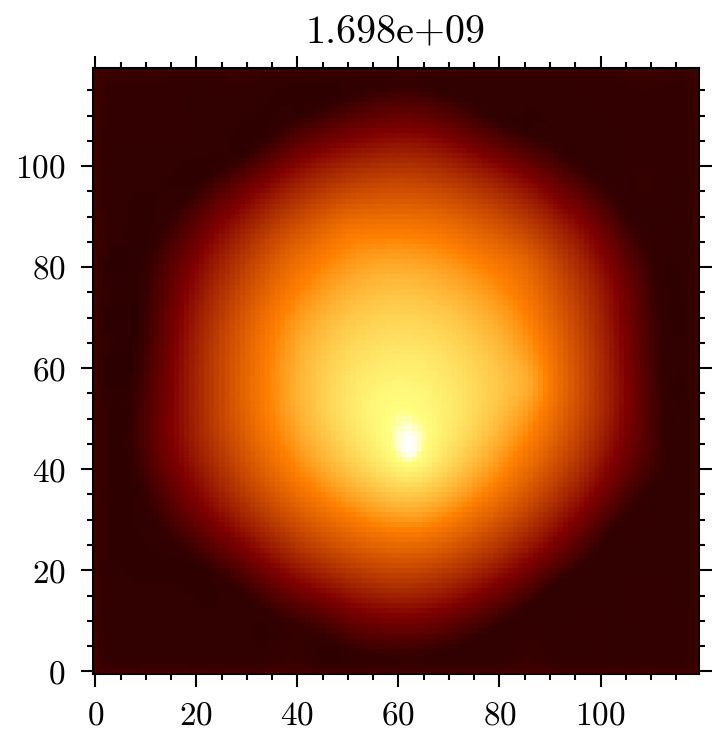

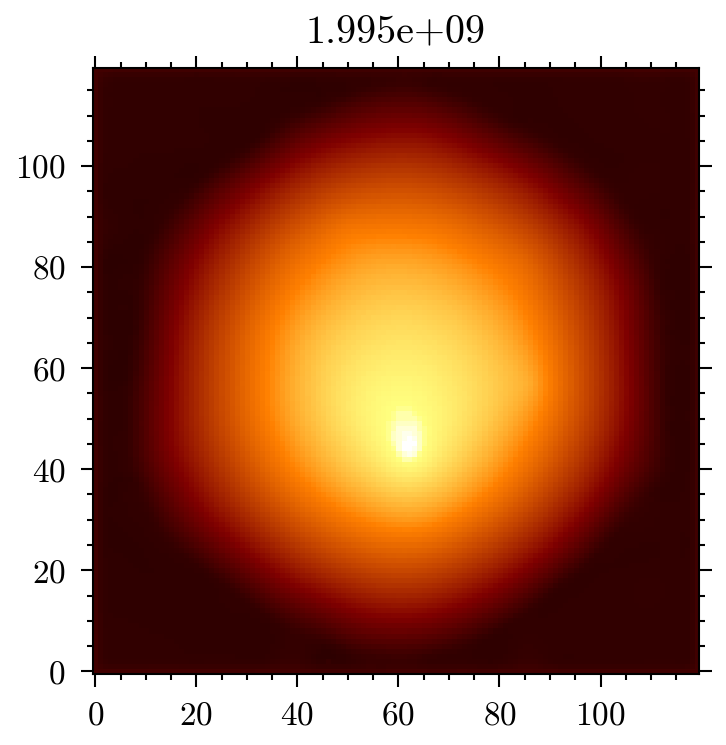

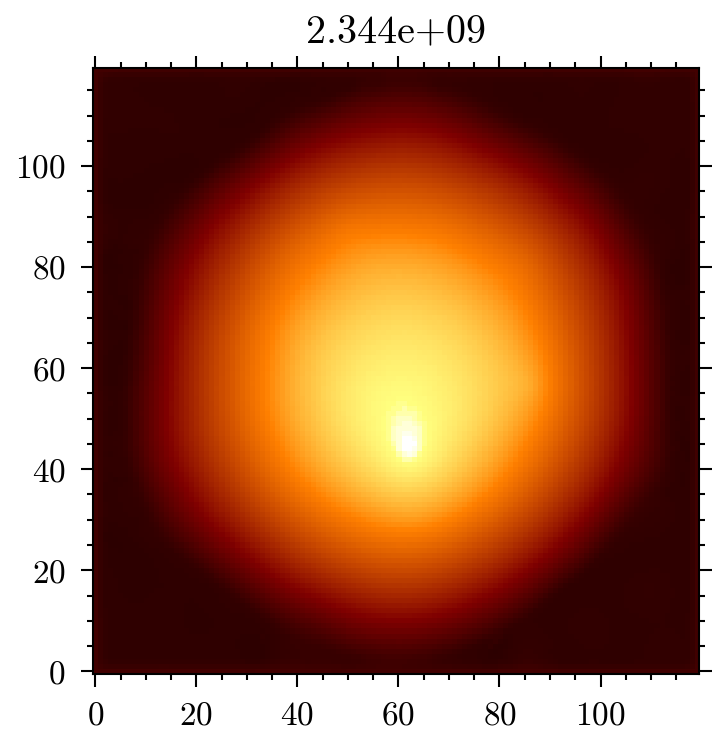

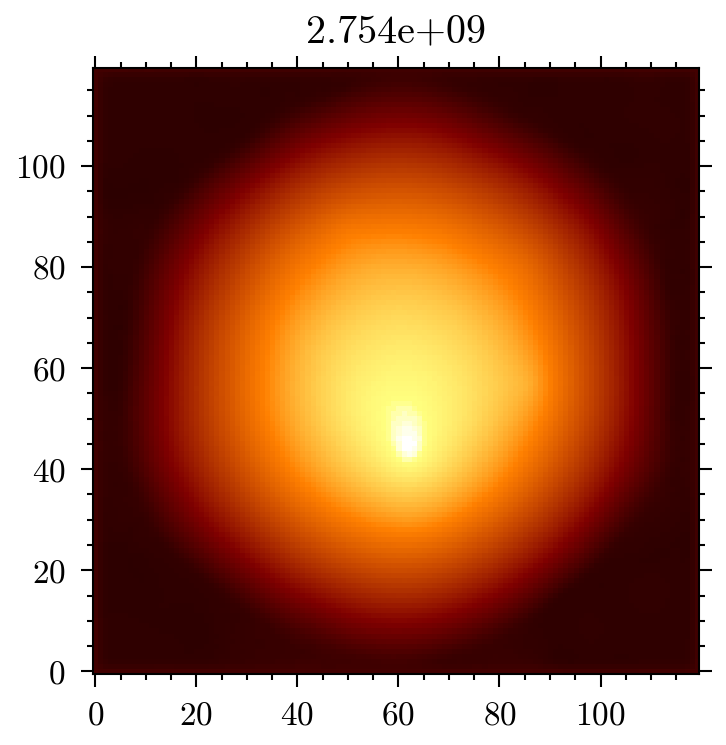

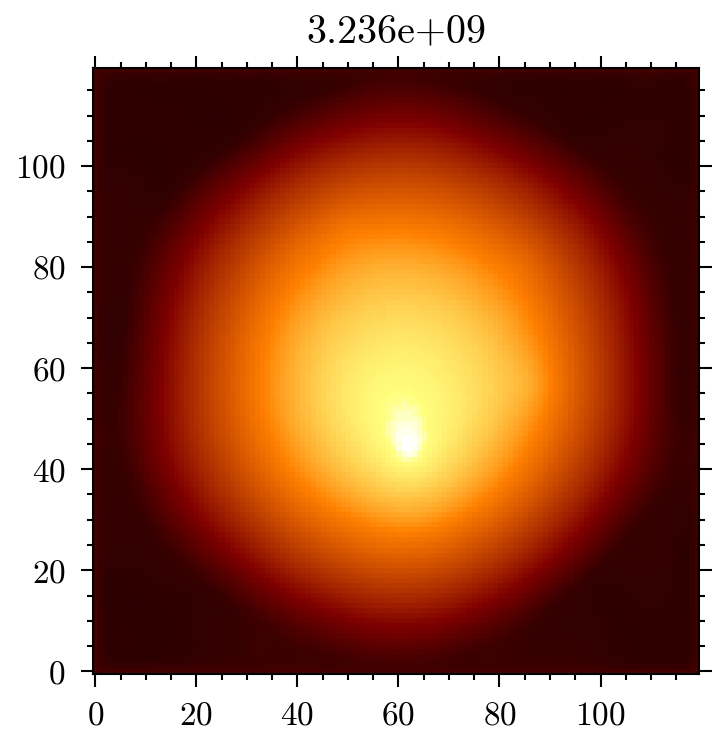

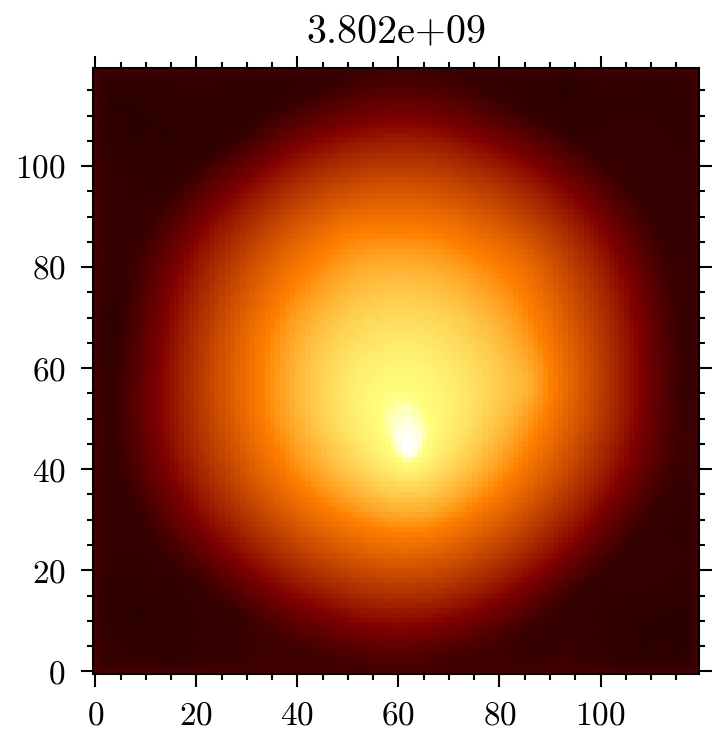

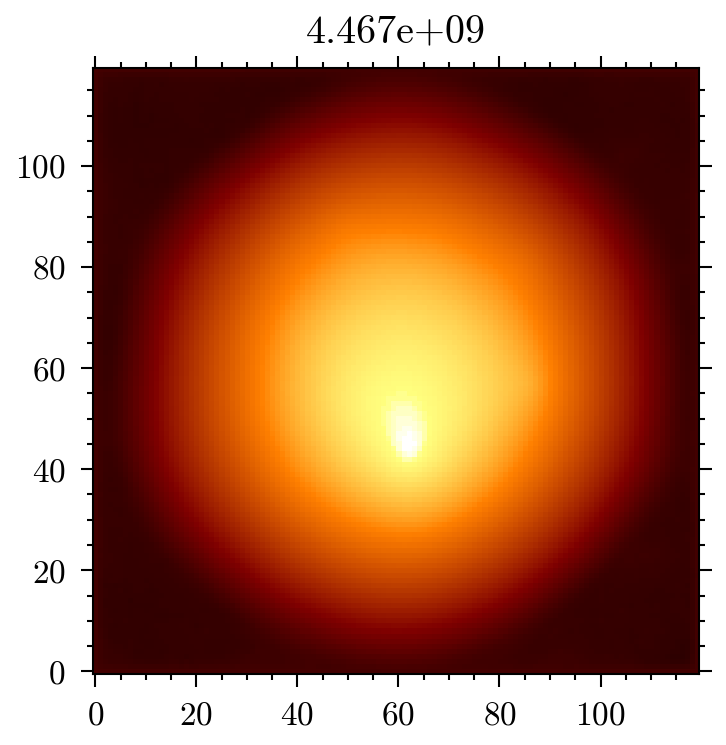

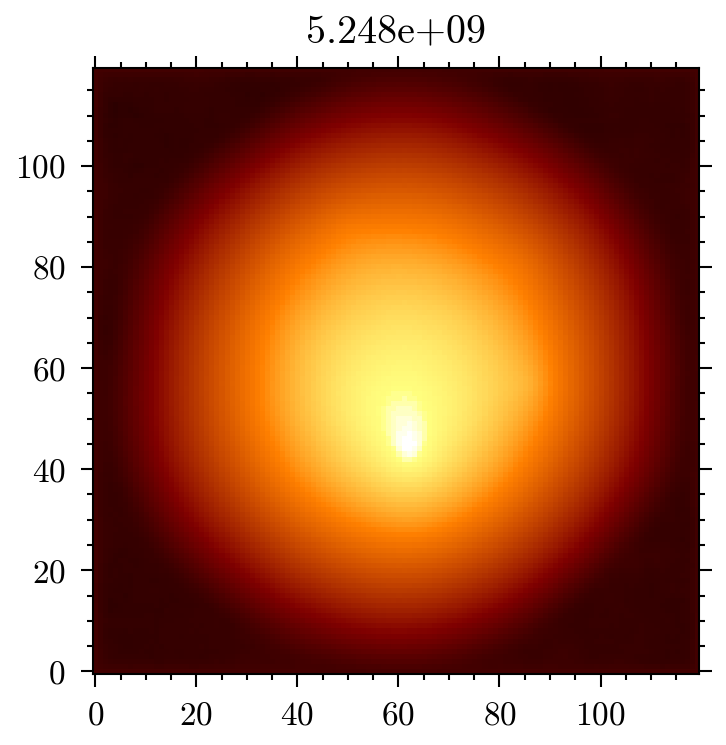

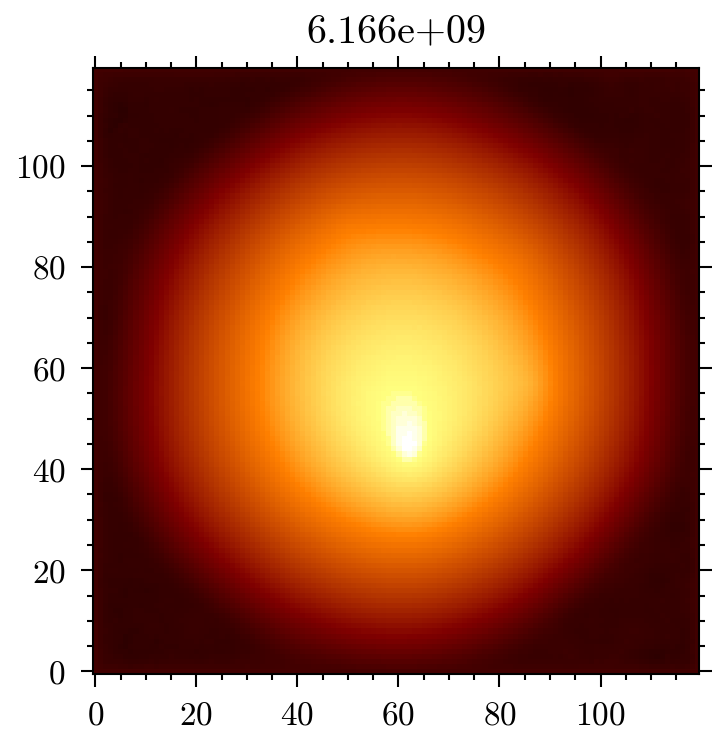

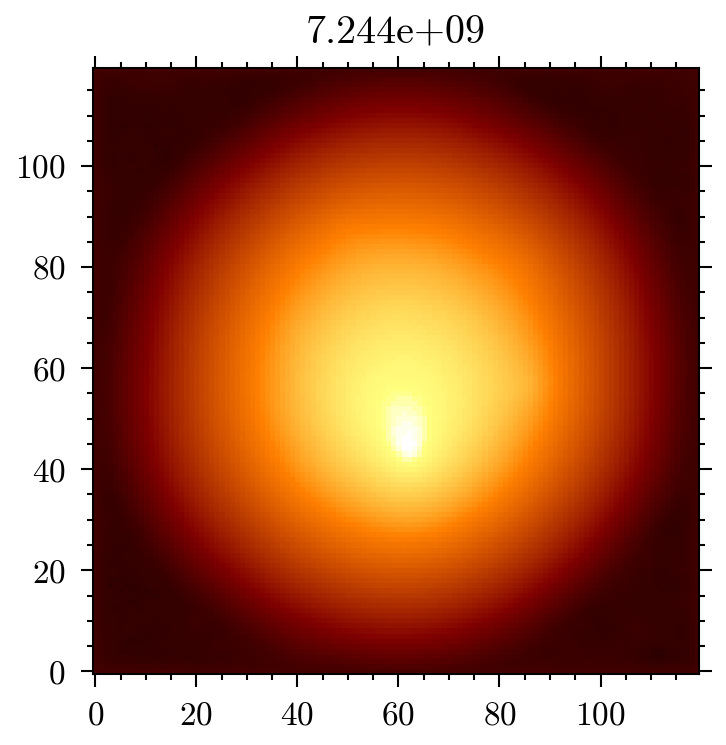

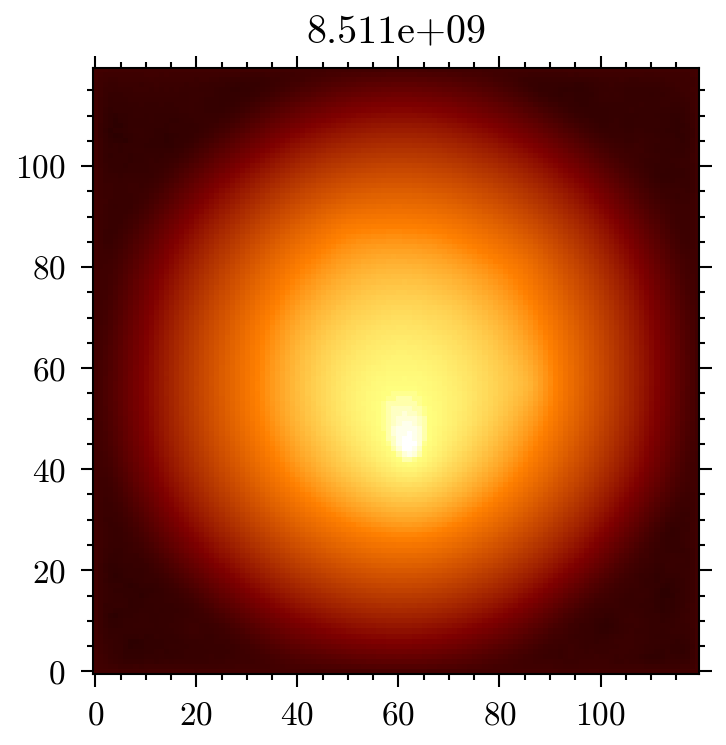

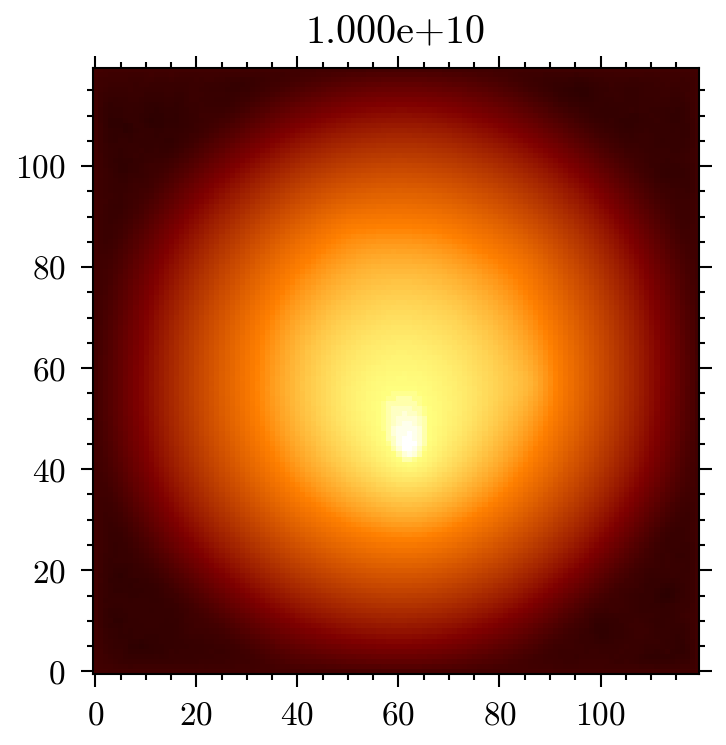

In [36]:
for i, l in enumerate(log_dists):
    plt.imshow(10 ** l["F430M"], norm=mpl.colors.PowerNorm(0.5), cmap="afmhot_10u")
    plt.title(f"{coeffs[i]:.3e}")
    plt.show()

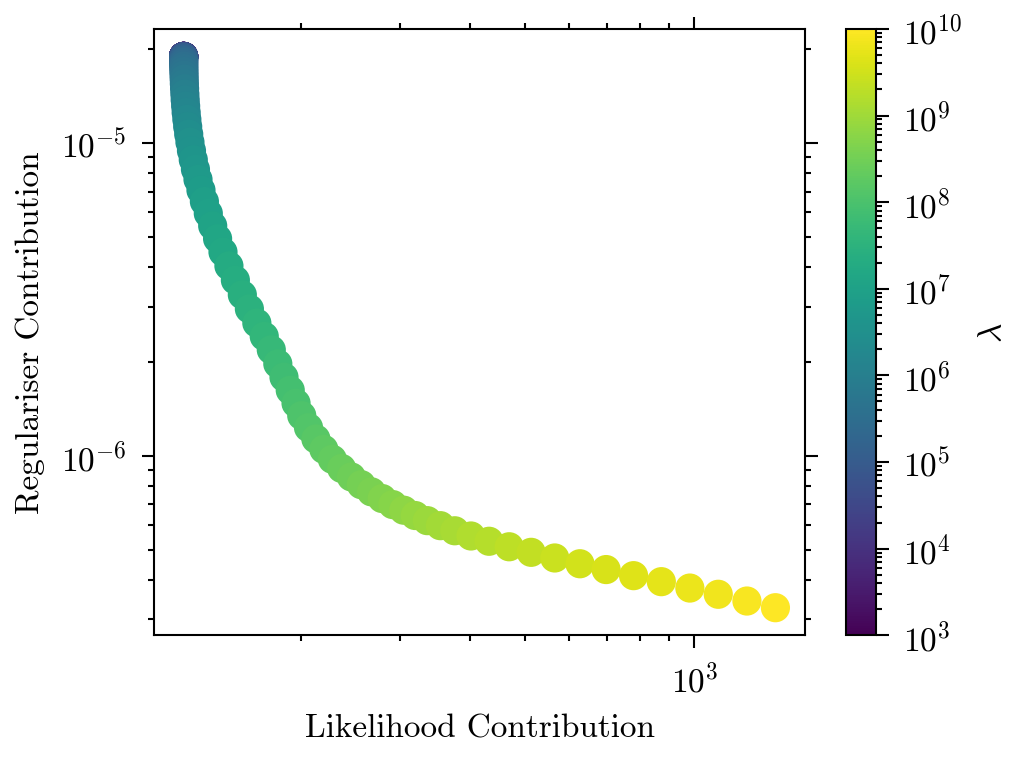

In [35]:
plt.figure()
plt.scatter(
    sweep[0],
    sweep[1],
    c=coeffs,
    cmap="viridis",
    norm=mpl.colors.LogNorm(),
)

plt.xscale("log")
plt.yscale("log")
plt.colorbar(label=r"$\lambda$")
plt.xlabel("Likelihood Contribution")
plt.ylabel("Regulariser Contribution")
plt.show()

In [29]:
final_model, losses, state, histories = amigo.fitting.optimise(
    model,
    # pds_sci_exposures,
    fits,
    fishers=fishers,
    optimisers=config,
    args=args,
    # norm_fn=dorito.stats.normalise_wavelets,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/250 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 303.94
Est time per epoch:  0:00:00
Est run time:  0:00:44
Full Time: 0:00:44
Final Loss: 120.82


In [30]:
model.ramp.values

Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

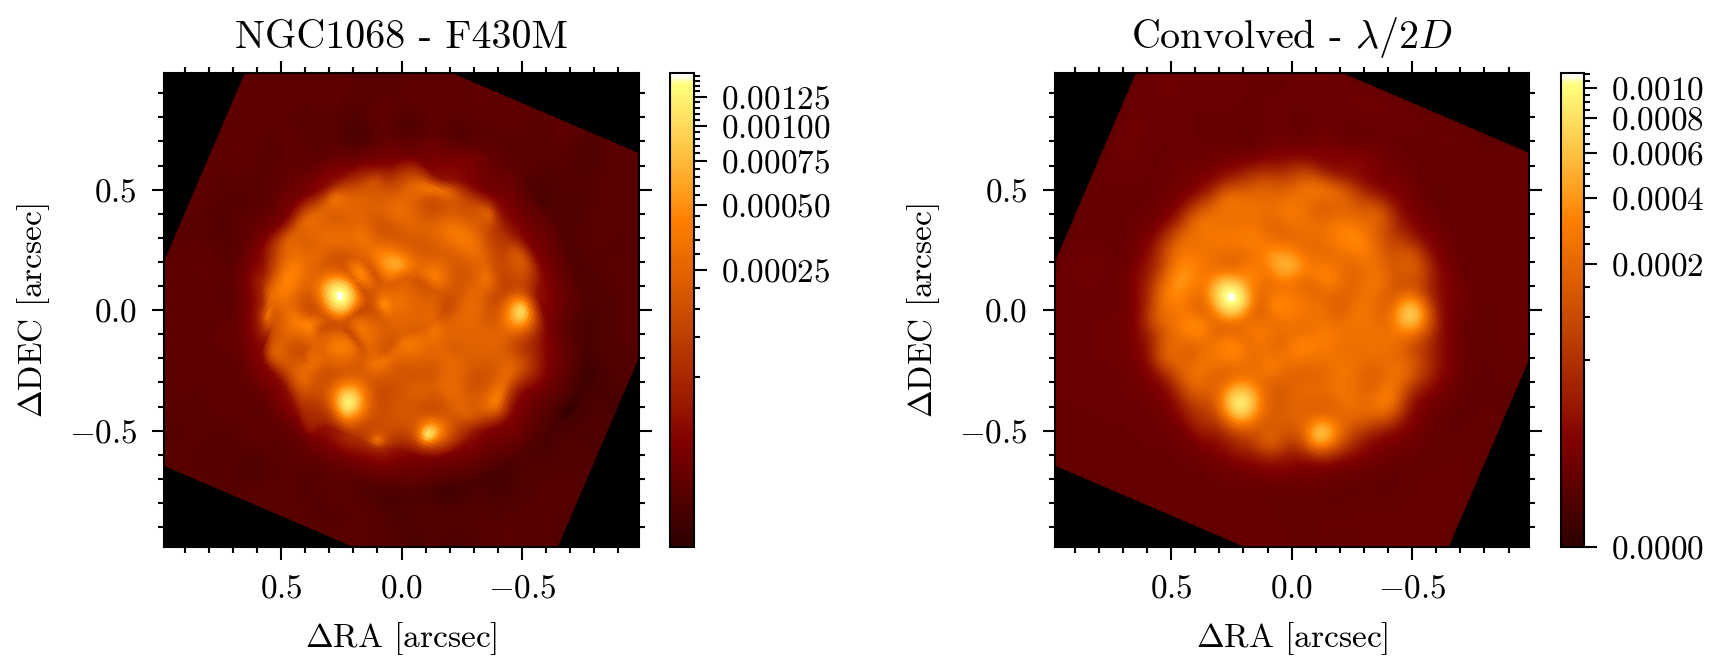

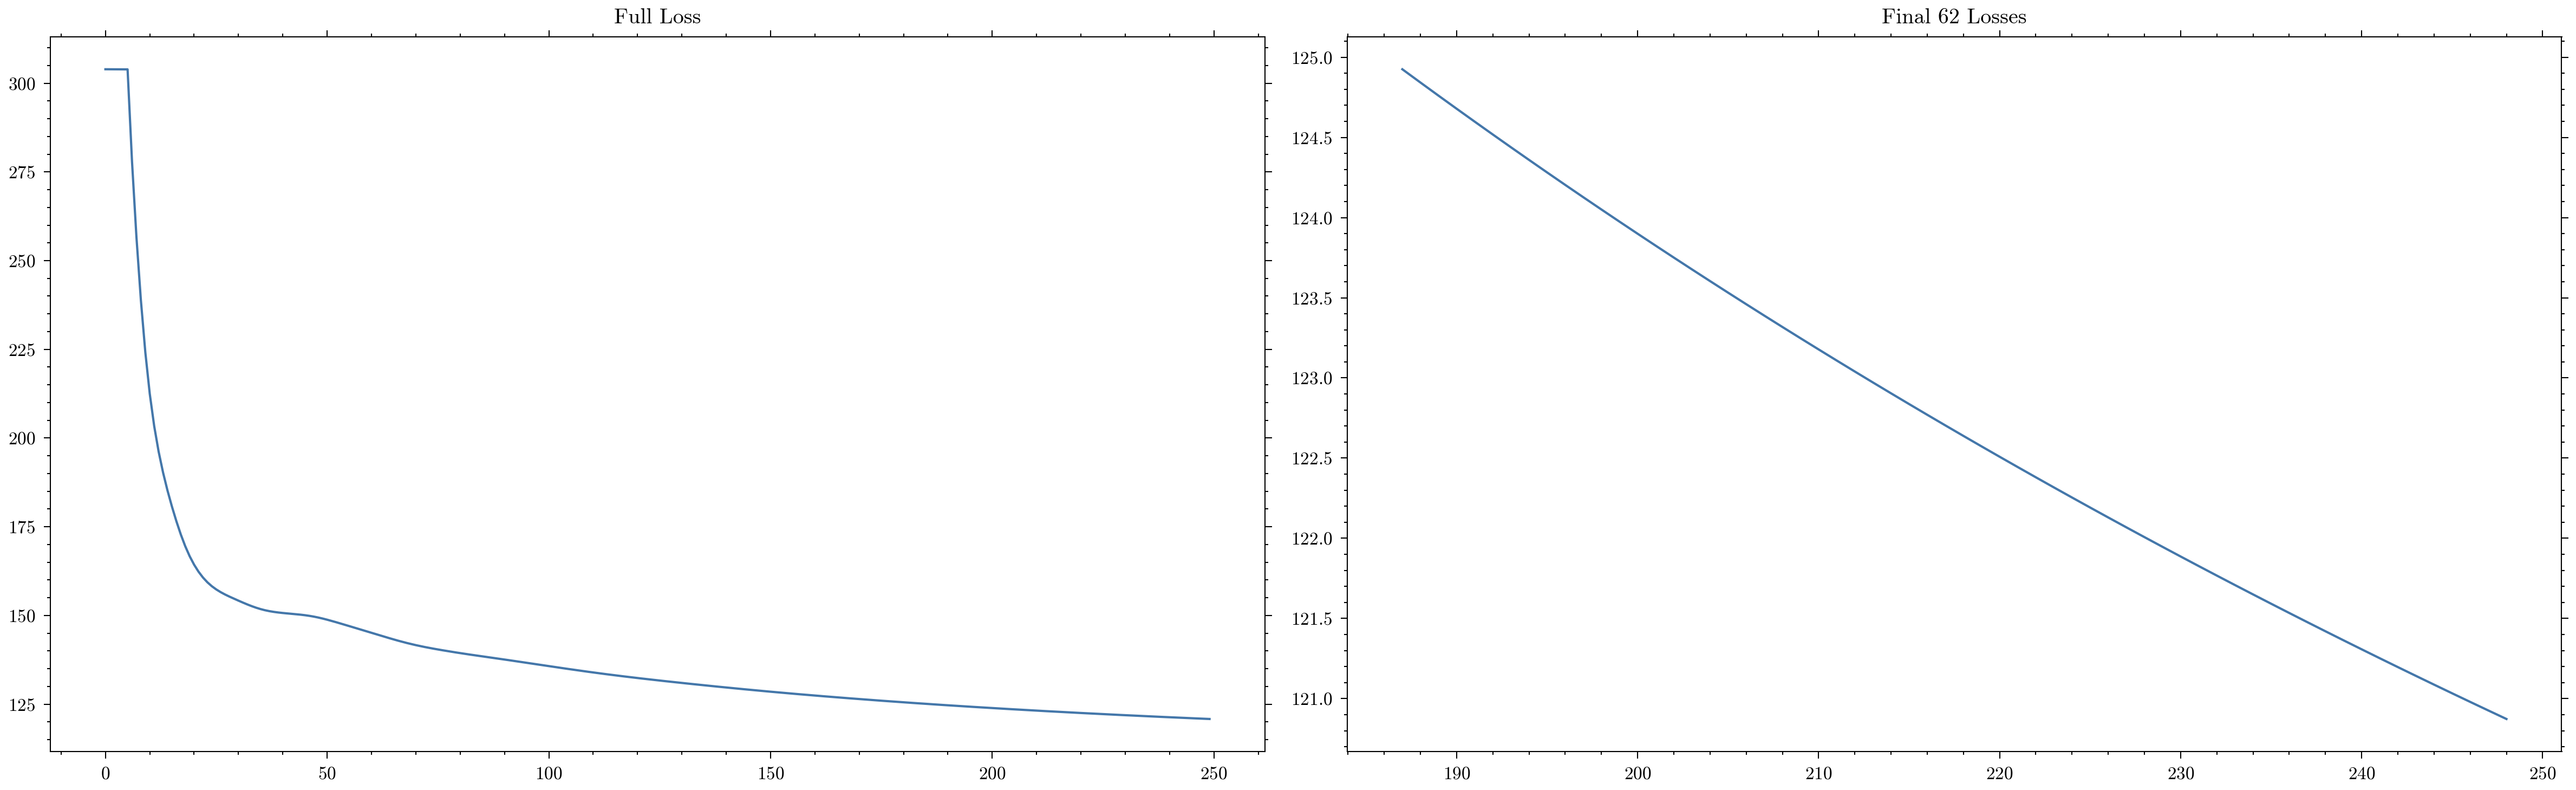

No formatting function for log_distribution


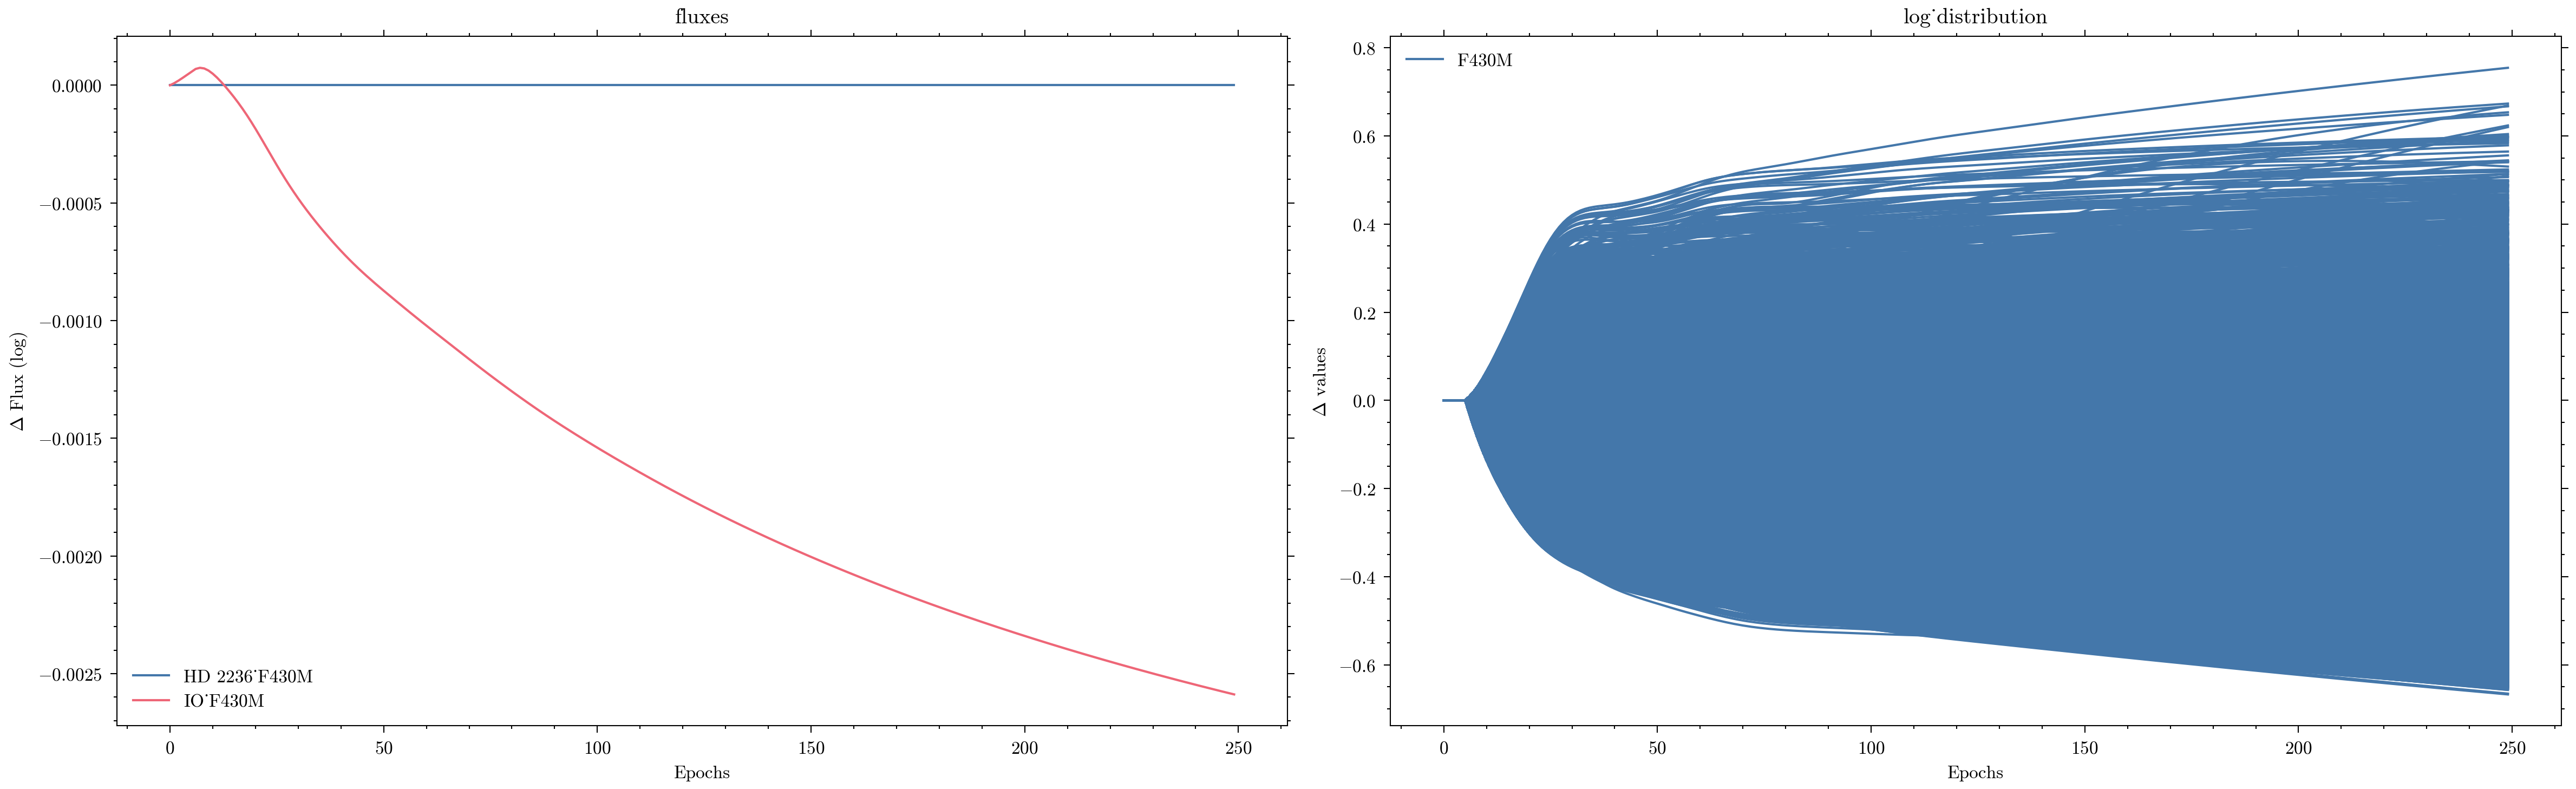

File 01373_017_02_04_3
Star IO
Filter F430M
nints 100
ngroups 18



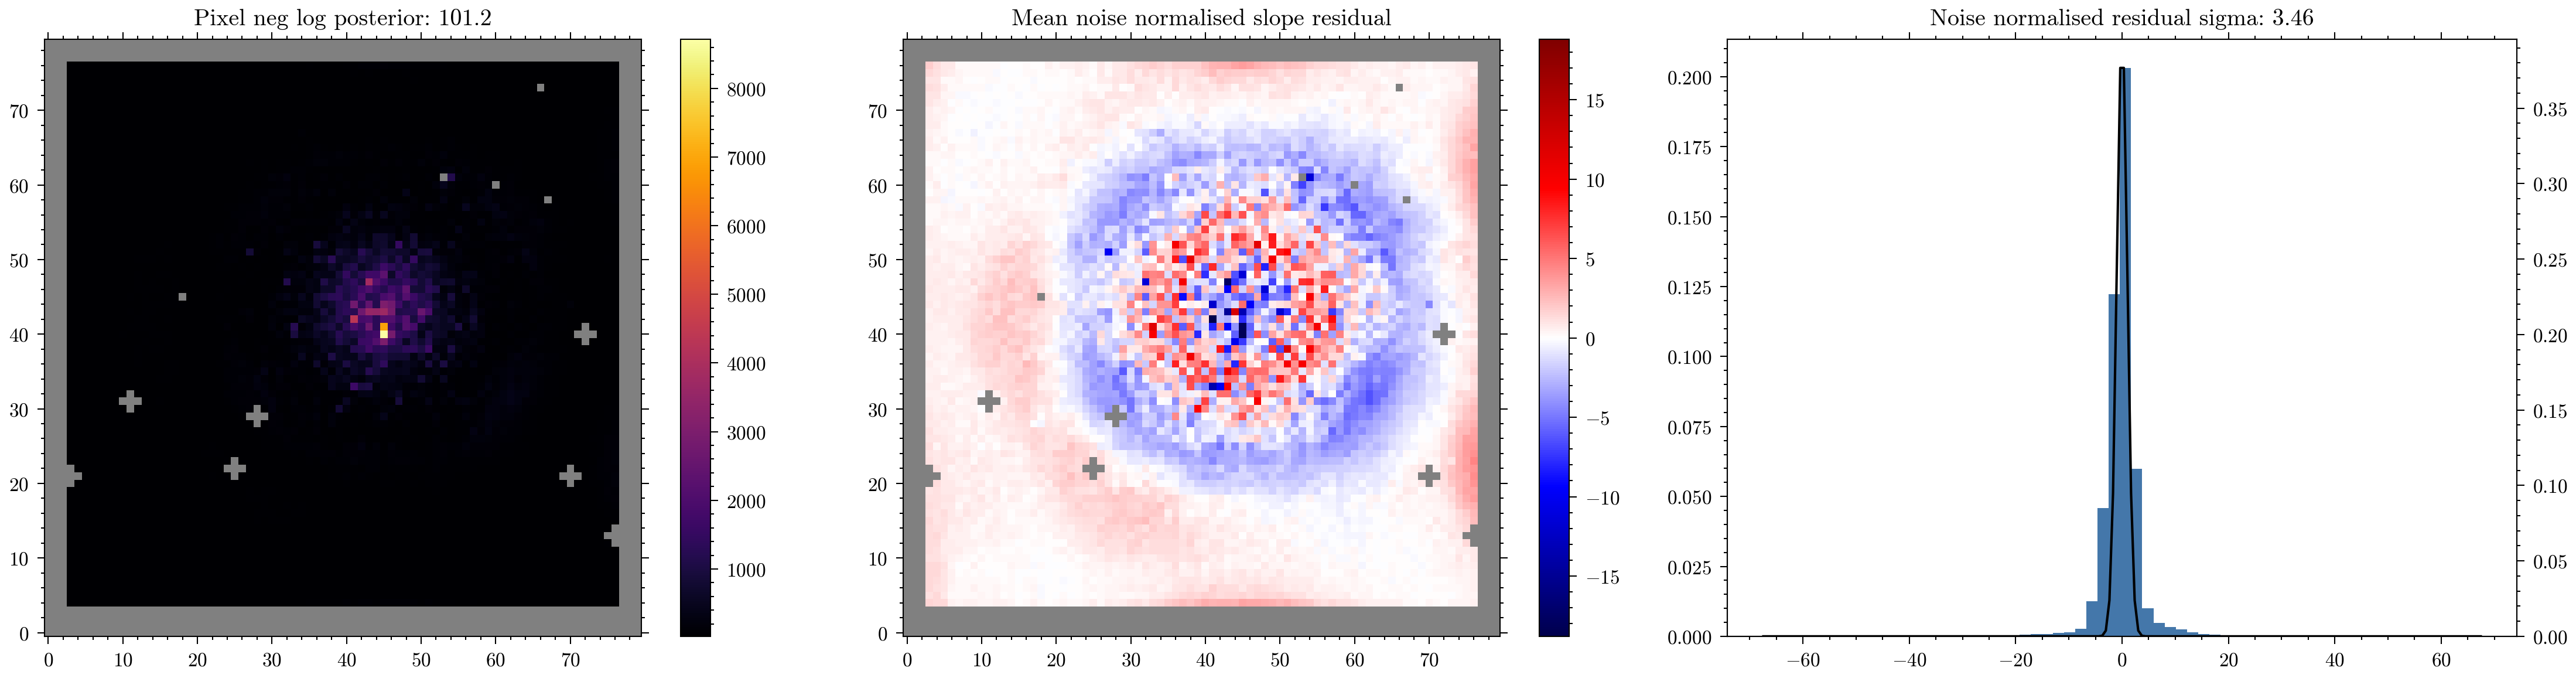

In [31]:
# np.save(init_state_cache + "F430M.npy", state.params)

flag = False
for exp in fits:

    try:
        if not flag:
            dist = final_model.get_distribution(exp)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=None,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, final_model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"NGC1068 - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(save_dir + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        flag = True
    except:
        continue


amigo.plotting.plot_losses(losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(histories)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        final_model,
        exp,
        # test_model,
    )

In [ ]:
np.sum(10 ** final_model.log_distribution["F430M"])